# Notebook 06: Equity decomposition

Companion to **`05_posterior_analysis.ipynb`**. The opening cells only need tables under **`artifacts/tables/`** (works when `data/` is not checked in). Later parts load posteriors, the accessibility bundle, and tract shapefiles from **`data/`** after you run the pipeline.

**Wasserstein-only pass (no `data/` required)**  
- Reads: `artifacts/tables/pipeline/pipeline__05_wasserstein_tract__{RID}.csv` and the latest `artifacts/tables/eda/eda__acs_sd_tract_attributes__*.csv`  
- Writes: `pipeline__06_wasserstein_equity_metrics__{RID}.csv`, `pipeline__06_wasserstein_by_disadv_quartile__{RID}.csv`, `pipeline__06_inputs_index__{RID}.csv` (under `artifacts/tables/pipeline/`)

Default run id: `PIPELINE_RUN_ID=fit_raw_zscore_x` if unset.

**Next notebook:** `07_intervention_simulation.ipynb`


In [1]:
from __future__ import annotations

import os
from pathlib import Path

import numpy as np
import pandas as pd
from scipy.stats import spearmanr, rankdata


def find_repo_root() -> Path:
    start = Path.cwd().resolve()
    for d in [start, *start.parents]:
        if (d / "configs" / "san_diego.yaml").exists() and (d / "artifacts").exists():
            return d
    for d in [start, *start.parents]:
        if (d / "context" / "PROJECT_BRIEF.md").exists() and (d / "artifacts").exists():
            return d
    raise FileNotFoundError(
        "Could not locate repo root (expected configs/san_diego.yaml + artifacts/, "
        "or context/PROJECT_BRIEF.md + artifacts/)"
    )


REPO_ROOT = find_repo_root()
RID = os.environ.get('PIPELINE_RUN_ID', 'fit_raw_zscore_x')
PIPE_TABLES = REPO_ROOT / 'artifacts' / 'tables' / 'pipeline'
EDA_TABLES = REPO_ROOT / 'artifacts' / 'tables' / 'eda'
PIPE_TABLES.mkdir(parents=True, exist_ok=True)


def out_table(stem: str) -> Path:
    return PIPE_TABLES / f'pipeline__06_{stem}__{RID}.csv'


print(f'REPO_ROOT={REPO_ROOT}')
print(f'RID={RID}')


REPO_ROOT=C:\Users\sardo\OneDrive\Desktop\Classes\Projects\BayesTransitEquity
RID=fit_raw_zscore_x


In [2]:
# Load committed artifact inputs
wasserstein_path = PIPE_TABLES / f'pipeline__05_wasserstein_tract__{RID}.csv'
_acs_candidates = sorted(EDA_TABLES.glob('eda__acs_sd_tract_attributes__*.csv'))
if not _acs_candidates:
    raise FileNotFoundError(f'No eda__acs_sd_tract_attributes__*.csv under {EDA_TABLES}')
acs_path = _acs_candidates[-1]

if not wasserstein_path.exists():
    raise FileNotFoundError(f'Missing required table: {wasserstein_path}')

w = pd.read_csv(wasserstein_path, dtype={'GEOID': str})
w['GEOID'] = w['GEOID'].str.zfill(11)

acs = pd.read_csv(acs_path, dtype={'GEOID': str})
acs['GEOID'] = acs['GEOID'].str.zfill(11)

w_col = next(c for c in w.columns if c != 'GEOID')
master = w.merge(acs, on='GEOID', how='left')

if 'disadvantage_z' not in master.columns:
    raise KeyError("ACS table missing 'disadvantage_z'")

pop_col = next((c for c in ['total_pop', 'pop', 'population', 'population_total', 'pop_total'] if c in master.columns), None)
if pop_col is None:
    master['__pop_weight'] = 1.0
    pop_col = '__pop_weight'

master = master.dropna(subset=[w_col, 'disadvantage_z']).copy()
master[pop_col] = pd.to_numeric(master[pop_col], errors='coerce').fillna(1).clip(lower=1)

print(f'Master rows: {len(master)}')
print(f'Wasserstein column: {w_col}')
print(f'Population weight column: {pop_col}')


Master rows: 720
Wasserstein column: wasserstein_topq_reference_pool
Population weight column: __pop_weight


In [3]:
def gini_weighted(values: np.ndarray, weights: np.ndarray) -> float:
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)
    v = values - np.nanmin(values) + 1e-9  # force non-negative support for Gini
    idx = np.argsort(v)
    v, wgt = v[idx], weights[idx]
    w_cum = np.cumsum(wgt)
    total_w = w_cum[-1]
    total_wv = np.sum(wgt * v)
    return float((2 * np.sum(wgt * v * (w_cum - wgt / 2)) / (total_w * total_wv)) - 1)


def concentration_index(y: np.ndarray, rank_var: np.ndarray) -> float:
    n = len(y)
    r = rankdata(rank_var) / n
    mu = np.mean(y)
    if mu == 0:
        return 0.0
    return float(2 * np.cov(y, r)[0, 1] / mu)


vals = master[w_col].to_numpy(dtype=float)
pop = master[pop_col].to_numpy(dtype=float)
disadv = master['disadvantage_z'].to_numpy(dtype=float)

rho, p = spearmanr(vals, disadv)
gini = gini_weighted(vals, pop)
ci = concentration_index(vals, disadv)

equity = pd.DataFrame([
    {
        'metric': 'spearman_wasserstein_vs_disadvantage_z',
        'value': float(rho),
        'p_value': float(p),
        'interpretation': 'Positive means more disadvantaged tracts are further from well-served reference distributions.'
    },
    {
        'metric': 'gini_wasserstein_population_weighted',
        'value': float(gini),
        'p_value': float('nan'),
        'interpretation': 'Inequality in Wasserstein burden across tracts (population-weighted).'
    },
    {
        'metric': 'concentration_index_wasserstein_vs_disadvantage_z',
        'value': float(ci),
        'p_value': float('nan'),
        'interpretation': 'Positive means Wasserstein burden concentrates among high-disadvantage tracts.'
    },
])

p_out = out_table('wasserstein_equity_metrics')
equity.to_csv(p_out, index=False)
print(equity)
print(f'Saved: {p_out}')


                                              metric     value       p_value  \
0             spearman_wasserstein_vs_disadvantage_z -0.360367  1.677603e-23   
1               gini_wasserstein_population_weighted  0.325186           NaN   
2  concentration_index_wasserstein_vs_disadvantage_z -0.055963           NaN   

                                      interpretation  
0  Positive means more disadvantaged tracts are f...  
1  Inequality in Wasserstein burden across tracts...  
2  Positive means Wasserstein burden concentrates...  
Saved: C:\Users\sardo\OneDrive\Desktop\Classes\Projects\BayesTransitEquity\artifacts\tables\pipeline\pipeline__06_wasserstein_equity_metrics__fit_raw_zscore_x.csv


In [4]:
df = master[['GEOID', w_col, 'disadvantage_z', pop_col]].copy()
df['disadv_q'] = pd.qcut(df['disadvantage_z'], q=4, labels=['Q1 (least)', 'Q2', 'Q3', 'Q4 (most)'])

rows = []
for q, g in df.groupby('disadv_q', observed=True):
    v = g[w_col].to_numpy(float)
    wgt = g[pop_col].to_numpy(float)
    rows.append({
        'disadv_quartile': str(q),
        'n_tracts': int(len(g)),
        'wasserstein_mean': float(np.mean(v)),
        'wasserstein_median': float(np.median(v)),
        'wasserstein_p25': float(np.percentile(v, 25)),
        'wasserstein_p75': float(np.percentile(v, 75)),
        'pop_weighted_mean': float(np.average(v, weights=wgt)),
    })

quart = pd.DataFrame(rows)
p_out = out_table('wasserstein_by_disadv_quartile')
quart.to_csv(p_out, index=False)
print(quart)
print(f'Saved: {p_out}')


  disadv_quartile  n_tracts  wasserstein_mean  wasserstein_median  \
0      Q1 (least)       180      31512.106393        33682.759866   
1              Q2       180      31037.700256        32608.746540   
2              Q3       180      27114.141859        27567.129400   
3       Q4 (most)       180      24236.783818        22678.705258   

   wasserstein_p25  wasserstein_p75  pop_weighted_mean  
0     27179.562064     36698.178529       31512.106393  
1     26532.031657     36727.307103       31037.700256  
2     20330.432800     33598.863884       27114.141859  
3     16331.974436     28597.372495       24236.783818  
Saved: C:\Users\sardo\OneDrive\Desktop\Classes\Projects\BayesTransitEquity\artifacts\tables\pipeline\pipeline__06_wasserstein_by_disadv_quartile__fit_raw_zscore_x.csv


In [4]:
# Reproducibility index
index_df = pd.DataFrame([
    {'key': 'nb05_wasserstein', 'path': str(wasserstein_path), 'exists': bool(wasserstein_path.exists())},
    {'key': 'acs_tract_attributes', 'path': str(acs_path), 'exists': bool(acs_path.exists())},
])

p_out = out_table('inputs_index')
index_df.to_csv(p_out, index=False)
print(index_df)
print(f'Saved: {p_out}')


                    key                                               path  \
0      nb05_wasserstein  C:\Users\sardo\OneDrive\Desktop\Classes\Projec...   
1  acs_tract_attributes  C:\Users\sardo\OneDrive\Desktop\Classes\Projec...   

   exists  
0    True  
1    True  
Saved: C:\Users\sardo\OneDrive\Desktop\Classes\Projects\BayesTransitEquity\artifacts\tables\pipeline\pipeline__06_inputs_index__fit_raw_zscore_x.csv


---


In [5]:
from __future__ import annotations

import os
from pathlib import Path

import numpy as np
import pandas as pd
from scipy.stats import spearmanr, rankdata


def find_repo_root() -> Path:
    start = Path.cwd().resolve()
    for d in [start, *start.parents]:
        if (d / "configs" / "san_diego.yaml").exists() and (d / "artifacts").exists():
            return d
    for d in [start, *start.parents]:
        if (d / "context" / "PROJECT_BRIEF.md").exists() and (d / "artifacts").exists():
            return d
    raise FileNotFoundError(
        "Could not locate repo root (expected configs/san_diego.yaml + artifacts/, "
        "or context/PROJECT_BRIEF.md + artifacts/)"
    )


REPO_ROOT = find_repo_root()
RID = os.environ.get('PIPELINE_RUN_ID', 'fit_raw_zscore_x')
PIPE_TABLES = REPO_ROOT / 'artifacts' / 'tables' / 'pipeline'
EDA_TABLES = REPO_ROOT / 'artifacts' / 'tables' / 'eda'
PIPE_TABLES.mkdir(parents=True, exist_ok=True)


def out_table(stem: str) -> Path:
    return PIPE_TABLES / f'pipeline__06_{stem}__{RID}.csv'


print(f'REPO_ROOT={REPO_ROOT}')
print(f'RID={RID}')


REPO_ROOT=C:\Users\sardo\OneDrive\Desktop\Classes\Projects\BayesTransitEquity
RID=fit_raw_zscore_x


In [6]:
wasserstein_path = PIPE_TABLES / f'pipeline__05_wasserstein_tract__{RID}.csv'
acs_path = EDA_TABLES / 'eda__acs_sd_tract_attributes__2026-03-29.csv'

w = pd.read_csv(wasserstein_path, dtype={'GEOID': str})
w['GEOID'] = w['GEOID'].str.zfill(11)
w_col = [c for c in w.columns if c != 'GEOID'][0]

acs = pd.read_csv(acs_path, dtype={'GEOID': str})
acs['GEOID'] = acs['GEOID'].str.zfill(11)

master = w.merge(acs, on='GEOID', how='left')

pop_col = None
for c in ['total_pop', 'pop', 'population', 'population_total', 'pop_total']:
    if c in master.columns:
        pop_col = c
        break
if pop_col is None:
    master['__pop_weight'] = 1.0
    pop_col = '__pop_weight'

master = master.dropna(subset=[w_col, 'disadvantage_z']).copy()
master[pop_col] = pd.to_numeric(master[pop_col], errors='coerce').fillna(1).clip(lower=1)

print(f'Master rows: {len(master)}')
print(f'wasserstein_col: {w_col}')
print(f'pop_col: {pop_col}')


Master rows: 720
wasserstein_col: wasserstein_topq_reference_pool
pop_col: __pop_weight


In [7]:
def gini_weighted(values: np.ndarray, weights: np.ndarray) -> float:
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)
    v = values - np.nanmin(values) + 1e-9
    idx = np.argsort(v)
    v, wgt = v[idx], weights[idx]
    w_cum = np.cumsum(wgt)
    total_w = w_cum[-1]
    total_wv = np.sum(wgt * v)
    return float((2 * np.sum(wgt * v * (w_cum - wgt / 2)) / (total_w * total_wv)) - 1)


def concentration_index(y: np.ndarray, rank_var: np.ndarray) -> float:
    n = len(y)
    r = rankdata(rank_var) / n
    mu = np.mean(y)
    if mu == 0:
        return 0.0
    return float(2 * np.cov(y, r)[0, 1] / mu)


vals = master[w_col].to_numpy(dtype=float)
pop = master[pop_col].to_numpy(dtype=float)
disadv = master['disadvantage_z'].to_numpy(dtype=float)

rho, p = spearmanr(vals, disadv)
gini = gini_weighted(vals, pop)
ci = concentration_index(vals, disadv)

equity = pd.DataFrame([
    {'metric': 'spearman_wasserstein_vs_disadvantage_z', 'value': float(rho), 'p_value': float(p)},
    {'metric': 'gini_wasserstein_population_weighted', 'value': float(gini), 'p_value': float('nan')},
    {'metric': 'concentration_index_wasserstein_vs_disadvantage_z', 'value': float(ci), 'p_value': float('nan')},
])

p_out = out_table('wasserstein_equity_metrics')
equity.to_csv(p_out, index=False)
print(equity)
print(f'Saved: {p_out}')


                                              metric     value       p_value
0             spearman_wasserstein_vs_disadvantage_z -0.360367  1.677603e-23
1               gini_wasserstein_population_weighted  0.325186           NaN
2  concentration_index_wasserstein_vs_disadvantage_z -0.055963           NaN
Saved: C:\Users\sardo\OneDrive\Desktop\Classes\Projects\BayesTransitEquity\artifacts\tables\pipeline\pipeline__06_wasserstein_equity_metrics__fit_raw_zscore_x.csv


In [8]:
df = master[['GEOID', w_col, 'disadvantage_z', pop_col]].copy()
df['disadv_q'] = pd.qcut(df['disadvantage_z'], q=4, labels=['Q1 (least)', 'Q2', 'Q3', 'Q4 (most)'])

rows = []
for q, g in df.groupby('disadv_q', observed=True):
    v = g[w_col].to_numpy(float)
    wgt = g[pop_col].to_numpy(float)
    rows.append({
        'disadv_quartile': str(q),
        'n_tracts': int(len(g)),
        'wasserstein_mean': float(np.mean(v)),
        'wasserstein_median': float(np.median(v)),
        'wasserstein_p25': float(np.percentile(v, 25)),
        'wasserstein_p75': float(np.percentile(v, 75)),
        'pop_weighted_mean': float(np.average(v, weights=wgt)),
    })

quart = pd.DataFrame(rows)
p_out = out_table('wasserstein_by_disadv_quartile')
quart.to_csv(p_out, index=False)
print(quart)
print(f'Saved: {p_out}')


  disadv_quartile  n_tracts  wasserstein_mean  wasserstein_median  \
0      Q1 (least)       180      31512.106393        33682.759866   
1              Q2       180      31037.700256        32608.746540   
2              Q3       180      27114.141859        27567.129400   
3       Q4 (most)       180      24236.783818        22678.705258   

   wasserstein_p25  wasserstein_p75  pop_weighted_mean  
0     27179.562064     36698.178529       31512.106393  
1     26532.031657     36727.307103       31037.700256  
2     20330.432800     33598.863884       27114.141859  
3     16331.974436     28597.372495       24236.783818  
Saved: C:\Users\sardo\OneDrive\Desktop\Classes\Projects\BayesTransitEquity\artifacts\tables\pipeline\pipeline__06_wasserstein_by_disadv_quartile__fit_raw_zscore_x.csv


In [9]:
index_df = pd.DataFrame([
    {'key': 'nb05_wasserstein', 'path': str(wasserstein_path), 'exists': bool(wasserstein_path.exists())},
    {'key': 'acs', 'path': str(acs_path), 'exists': bool(acs_path.exists())},
])

p_out = out_table('inputs_index')
index_df.to_csv(p_out, index=False)
print(index_df)
print(f'Saved: {p_out}')


                key                                               path  exists
0  nb05_wasserstein  C:\Users\sardo\OneDrive\Desktop\Classes\Projec...    True
1               acs  C:\Users\sardo\OneDrive\Desktop\Classes\Projec...    True
Saved: C:\Users\sardo\OneDrive\Desktop\Classes\Projects\BayesTransitEquity\artifacts\tables\pipeline\pipeline__06_inputs_index__fit_raw_zscore_x.csv


---


In [10]:
from __future__ import annotations

import os
from pathlib import Path

import numpy as np
import pandas as pd
from scipy.stats import spearmanr, rankdata


def find_repo_root() -> Path:
    start = Path.cwd().resolve()
    for d in [start, *start.parents]:
        if (d / "configs" / "san_diego.yaml").exists() and (d / "artifacts").exists():
            return d
    for d in [start, *start.parents]:
        if (d / "context" / "PROJECT_BRIEF.md").exists() and (d / "artifacts").exists():
            return d
    raise FileNotFoundError(
        "Could not locate repo root (expected configs/san_diego.yaml + artifacts/, "
        "or context/PROJECT_BRIEF.md + artifacts/)"
    )


REPO_ROOT = find_repo_root()
RID = os.environ.get("PIPELINE_RUN_ID", "fit_raw_zscore_x")

PIPE_TABLES = REPO_ROOT / "artifacts" / "tables" / "pipeline"
EDA_TABLES = REPO_ROOT / "artifacts" / "tables" / "eda"
PIPE_TABLES.mkdir(parents=True, exist_ok=True)


def out_table(stem: str) -> Path:
    return PIPE_TABLES / f"pipeline__06_{stem}__{RID}.csv"


print(f"REPO_ROOT={REPO_ROOT}")
print(f"RID={RID}")
print(f"PIPE_TABLES={PIPE_TABLES}")


REPO_ROOT=C:\Users\sardo\OneDrive\Desktop\Classes\Projects\BayesTransitEquity
RID=fit_raw_zscore_x
PIPE_TABLES=C:\Users\sardo\OneDrive\Desktop\Classes\Projects\BayesTransitEquity\artifacts\tables\pipeline


In [11]:
# ── Load committed inputs 
wasserstein_path = PIPE_TABLES / f"pipeline__05_wasserstein_tract__{RID}.csv"
if not wasserstein_path.exists():
    raise FileNotFoundError(f"Missing required table: {wasserstein_path}")

w = pd.read_csv(wasserstein_path, dtype={"GEOID": str})
w["GEOID"] = w["GEOID"].str.zfill(11)
w_col = [c for c in w.columns if c != "GEOID"][0]

acs_path = EDA_TABLES / "eda__acs_sd_tract_attributes__2026-03-29.csv"
if not acs_path.exists():
    raise FileNotFoundError(f"Missing required table: {acs_path}")

acs = pd.read_csv(acs_path, dtype={"GEOID": str})
acs["GEOID"] = acs["GEOID"].str.zfill(11)

# Join
master = w.merge(acs, on="GEOID", how="left")

if "disadvantage_z" not in master.columns:
    raise KeyError("ACS table missing 'disadvantage_z'")

# Choose a population weight column if present; otherwise unweighted
pop_col = None
for c in ["total_pop", "pop", "population", "population_total", "pop_total"]:
    if c in master.columns:
        pop_col = c
        break
if pop_col is None:
    master["__pop_weight"] = 1.0
    pop_col = "__pop_weight"

master = master.dropna(subset=[w_col, "disadvantage_z"]).copy()
master[pop_col] = pd.to_numeric(master[pop_col], errors="coerce").fillna(1).clip(lower=1)

print(f"Master: {master.shape}")
print(f"wasserstein_col={w_col!r}")
print(f"pop_col={pop_col!r}")


Master: (720, 25)
wasserstein_col='wasserstein_topq_reference_pool'
pop_col='__pop_weight'


In [12]:
def gini_weighted(values: np.ndarray, weights: np.ndarray) -> float:
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)
    v = values - np.nanmin(values) + 1e-9  # force non-negative
    idx = np.argsort(v)
    v, wgt = v[idx], weights[idx]
    w_cum = np.cumsum(wgt)
    total_w = w_cum[-1]
    total_wv = np.sum(wgt * v)
    return float((2 * np.sum(wgt * v * (w_cum - wgt / 2)) / (total_w * total_wv)) - 1)


def concentration_index(y: np.ndarray, rank_var: np.ndarray) -> float:
    n = len(y)
    r = rankdata(rank_var) / n
    mu = np.mean(y)
    if mu == 0:
        return 0.0
    return float(2 * np.cov(y, r)[0, 1] / mu)


vals = master[w_col].to_numpy(dtype=float)
pop = master[pop_col].to_numpy(dtype=float)
disadv = master["disadvantage_z"].to_numpy(dtype=float)

rho, p = spearmanr(vals, disadv)
gini = gini_weighted(vals, pop)
ci = concentration_index(vals, disadv)

equity = pd.DataFrame(
    [
        {
            "metric": "spearman_wasserstein_vs_disadvantage_z",
            "value": float(rho),
            "p_value": float(p),
            "note": "Positive => higher disadvantage ↔ larger Wasserstein distance",
        },
        {
            "metric": "gini_wasserstein_population_weighted",
            "value": float(gini),
            "p_value": float("nan"),
            "note": "Population-weighted inequality of Wasserstein distances across tracts",
        },
        {
            "metric": "concentration_index_wasserstein_vs_disadvantage_z",
            "value": float(ci),
            "p_value": float("nan"),
            "note": "Positive => Wasserstein burden concentrated among high-disadvantage tracts",
        },
    ]
)

p_out = out_table("wasserstein_equity_metrics")
equity.to_csv(p_out, index=False)
print(equity)
print(f"Saved: {p_out}")


                                              metric     value       p_value  \
0             spearman_wasserstein_vs_disadvantage_z -0.360367  1.677603e-23   
1               gini_wasserstein_population_weighted  0.325186           NaN   
2  concentration_index_wasserstein_vs_disadvantage_z -0.055963           NaN   

                                                note  
0  Positive => higher disadvantage ↔ larger Wasse...  
1  Population-weighted inequality of Wasserstein ...  
2  Positive => Wasserstein burden concentrated am...  
Saved: C:\Users\sardo\OneDrive\Desktop\Classes\Projects\BayesTransitEquity\artifacts\tables\pipeline\pipeline__06_wasserstein_equity_metrics__fit_raw_zscore_x.csv


In [13]:
# ── Quartile decomposition
df = master[["GEOID", w_col, "disadvantage_z", pop_col]].copy()
df["disadv_q"] = pd.qcut(df["disadvantage_z"], q=4, labels=["Q1 (least)", "Q2", "Q3", "Q4 (most)"])

rows = []
for q, g in df.groupby("disadv_q", observed=True):
    v = g[w_col].to_numpy(float)
    wgt = g[pop_col].to_numpy(float)
    rows.append(
        {
            "disadv_quartile": str(q),
            "n_tracts": int(len(g)),
            "wasserstein_mean": float(np.mean(v)),
            "wasserstein_median": float(np.median(v)),
            "wasserstein_p25": float(np.percentile(v, 25)),
            "wasserstein_p75": float(np.percentile(v, 75)),
            "pop_weighted_mean": float(np.average(v, weights=wgt)),
        }
    )

quart = pd.DataFrame(rows)
p_out = out_table("wasserstein_by_disadv_quartile")
quart.to_csv(p_out, index=False)
print(quart)
print(f"Saved: {p_out}")


  disadv_quartile  n_tracts  wasserstein_mean  wasserstein_median  \
0      Q1 (least)       180      31512.106393        33682.759866   
1              Q2       180      31037.700256        32608.746540   
2              Q3       180      27114.141859        27567.129400   
3       Q4 (most)       180      24236.783818        22678.705258   

   wasserstein_p25  wasserstein_p75  pop_weighted_mean  
0     27179.562064     36698.178529       31512.106393  
1     26532.031657     36727.307103       31037.700256  
2     20330.432800     33598.863884       27114.141859  
3     16331.974436     28597.372495       24236.783818  
Saved: C:\Users\sardo\OneDrive\Desktop\Classes\Projects\BayesTransitEquity\artifacts\tables\pipeline\pipeline__06_wasserstein_by_disadv_quartile__fit_raw_zscore_x.csv


In [14]:
# ── Input index for reproducibility 
paths = {
    "nb05_summary": PIPE_TABLES / f"pipeline__05_summary__{RID}.csv",
    "nb05_multithreshold": PIPE_TABLES / f"pipeline__05_multithreshold_equity__{RID}.csv",
    "nb05_rank_divergence": PIPE_TABLES / f"pipeline__05_rank_divergence__{RID}.csv",
    "nb05_hook_candidates": PIPE_TABLES / f"pipeline__05_hook_near_q25_exceedance_ambiguous__{RID}.csv",
    "nb05_wasserstein": wasserstein_path,
    "acs": acs_path,
}

index_df = pd.DataFrame(
    [{"key": k, "path": str(p), "exists": bool(p.exists())} for k, p in paths.items()]
)

p_out = out_table("inputs_index")
index_df.to_csv(p_out, index=False)
print(index_df)
print(f"Saved: {p_out}")


                    key                                               path  \
0          nb05_summary  C:\Users\sardo\OneDrive\Desktop\Classes\Projec...   
1   nb05_multithreshold  C:\Users\sardo\OneDrive\Desktop\Classes\Projec...   
2  nb05_rank_divergence  C:\Users\sardo\OneDrive\Desktop\Classes\Projec...   
3  nb05_hook_candidates  C:\Users\sardo\OneDrive\Desktop\Classes\Projec...   
4      nb05_wasserstein  C:\Users\sardo\OneDrive\Desktop\Classes\Projec...   
5                   acs  C:\Users\sardo\OneDrive\Desktop\Classes\Projec...   

   exists  
0    True  
1    True  
2    True  
3    True  
4    True  
5    True  
Saved: C:\Users\sardo\OneDrive\Desktop\Classes\Projects\BayesTransitEquity\artifacts\tables\pipeline\pipeline__06_inputs_index__fit_raw_zscore_x.csv


## Posterior-based analysis

From here on you need **`data/processed/`** (posteriors, accessibility bundle) plus tract geometry under **`data/raw/census/`**. Topics: Gini and concentration index on posterior jobs, subgroups, multi-destination equity, composite deficit, PPCs, LOO, prior sensitivity, Moran's I, drop-one covariates, then a summary CSV.

**Previous:** [05_posterior_analysis.ipynb](05_posterior_analysis.ipynb) · **Next:** [07_intervention_simulation.ipynb](07_intervention_simulation.ipynb)


## Environment and data load

In [15]:
from __future__ import annotations
import os, warnings
from pathlib import Path
import yaml
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats
from scipy.stats import spearmanr, rankdata
from scipy.special import logsumexp
warnings.filterwarnings('ignore', category=FutureWarning)

def find_repo_root() -> Path:
    start = Path.cwd().resolve()
    for d in [start, *start.parents]:
        if (d / "configs" / "san_diego.yaml").exists() and (d / "artifacts").exists():
            return d
    for d in [start, *start.parents]:
        if (d / "context" / "PROJECT_BRIEF.md").exists() and (d / "artifacts").exists():
            return d
    raise FileNotFoundError(
        "Could not locate repo root (expected configs/san_diego.yaml + artifacts/, "
        "or context/PROJECT_BRIEF.md + artifacts/)"
    )

REPO_ROOT = find_repo_root()
with open(REPO_ROOT / 'configs' / 'san_diego.yaml') as f:
    CITY = yaml.safe_load(f)
with open(REPO_ROOT / 'configs' / 'defaults.yaml') as f:
    DEFAULTS = yaml.safe_load(f)

print(f'REPO_ROOT = {REPO_ROOT}')
print(f'city = {CITY.get("city_label") or CITY.get("city")}')

REPO_ROOT = C:\Users\sardo\OneDrive\Desktop\Classes\Projects\BayesTransitEquity
city = San Diego, CA


In [17]:
# ── Config pin 
RID             = os.environ.get('PIPELINE_RUN_ID', 'fit_raw_zscore_x')
THRESHOLD_MIN   = int(os.environ.get('THRESHOLD_MIN', 45))
DESERT_QUANTILE = float(os.environ.get('DESERT_QUANTILE', 0.25))
N_DRAWS_SAMPLE  = int(os.environ.get('N_DRAWS_SAMPLE', 1000))  # draws for uncertainty propagation

ARTIFACT_TABLES  = REPO_ROOT / 'artifacts' / 'tables'
ARTIFACT_FIGURES = REPO_ROOT / 'artifacts' / 'figures'
ARTIFACT_TABLES.mkdir(parents=True, exist_ok=True)
ARTIFACT_FIGURES.mkdir(parents=True, exist_ok=True)

def artifact_table(stem: str) -> Path:
    return ARTIFACT_TABLES / f'pipeline__06_{stem}__{RID}.csv'

def artifact_figure(stem: str) -> Path:
    return ARTIFACT_FIGURES / f'pipeline__06_{stem}__{RID}.png'

print(f'RID={RID}  threshold={THRESHOLD_MIN}min  desert_q={DESERT_QUANTILE}  n_draws={N_DRAWS_SAMPLE}')

RID=fit_raw_zscore_x  threshold=45min  desert_q=0.25  n_draws=1000


In [18]:
# ── Load posterior summary 
post_summary_path = REPO_ROOT / 'data' / 'processed' / 'posteriors' / f'{RID}_posterior_summary.parquet'
posterior_summary = pd.read_parquet(post_summary_path)
print(f'Posterior summary: {posterior_summary.shape}  columns: {list(posterior_summary.columns[:8])}...')

Posterior summary: (720, 15)  columns: ['GEOID', 'posterior_mean_log1p', 'posterior_sd_log1p', 'ci_lower_95_log1p', 'ci_upper_95_log1p', 'posterior_mean_jobs', 'posterior_sd_jobs_delta', 'exceedance_prob_30min']...


In [19]:
# ── Load posterior samples (N_DRAWS_SAMPLE random rows for tractable computation) ──
post_samples_path = REPO_ROOT / 'data' / 'processed' / 'posteriors' / f'{RID}_posterior_samples.parquet'
all_samples = pd.read_parquet(post_samples_path)
print(f'Full samples: {all_samples.shape}')

# Pivot to wide format: rows=tracts, cols=draws
# Expected columns: GEOID, draw, mu (or posterior_jobs)
sample_cols = list(all_samples.columns)
print(f'Sample columns: {sample_cols[:10]}')

# Standardize tract id (parquet from nb04 uses lowercase 'geoid' per INTERFACES.md)
GEOID_COL = next((c for c in ('GEOID', 'geoid') if c in sample_cols), None)
if GEOID_COL is None:
    raise KeyError(f"No GEOID/geoid column in posterior samples; columns={sample_cols}")
if GEOID_COL != 'GEOID':
    all_samples = all_samples.rename(columns={GEOID_COL: 'GEOID'})
    sample_cols = list(all_samples.columns)

# Draw column: multi-chain long format resets sample_idx per chain — unique id = f(chain, sample_idx)
if 'draw' in all_samples.columns:
    PIVOT_DRAW_COL = 'draw'
elif 'sample_idx' in all_samples.columns and 'chain' in all_samples.columns:
    all_samples = all_samples.copy()
    smax = int(all_samples['sample_idx'].max()) + 1
    all_samples['_draw_uid'] = all_samples['chain'].to_numpy(dtype=np.int64) * smax + all_samples[
        'sample_idx'
    ].to_numpy(dtype=np.int64)
    PIVOT_DRAW_COL = '_draw_uid'
elif 'sample_idx' in all_samples.columns:
    PIVOT_DRAW_COL = 'sample_idx'
elif 'sample' in all_samples.columns:
    PIVOT_DRAW_COL = 'sample'
else:
    raise KeyError(f"No draw/sample_idx column in posterior samples; columns={sample_cols}")

# Value column — prefer latent mu names, then pipeline 'accessibility'
for candidate in ('mu', 'posterior_jobs', 'y_hat', 'mu_back', 'accessibility'):
    if candidate in all_samples.columns:
        MU_COL = candidate
        break
else:
    skip = {'GEOID', PIVOT_DRAW_COL}
    MU_COL = [c for c in all_samples.columns if c not in skip][-1]

print(f'Using pivot_draw_col={PIVOT_DRAW_COL!r}, mu_col={MU_COL!r}')

# Pivot: shape (n_tracts, n_draws)
samples_wide = all_samples.pivot(index='GEOID', columns=PIVOT_DRAW_COL, values=MU_COL)
print(f'Samples wide: {samples_wide.shape}  (tracts × draws)')

# Subsample draws for heavy computations
rng = np.random.default_rng(42)
if samples_wide.shape[1] > N_DRAWS_SAMPLE:
    draw_idx = rng.choice(samples_wide.shape[1], N_DRAWS_SAMPLE, replace=False)
    samples_sub = samples_wide.iloc[:, draw_idx]
else:
    samples_sub = samples_wide
print(f'Subsampled draws: {samples_sub.shape[1]}')

Full samples: (23040000, 4)
Sample columns: ['chain', 'sample_idx', 'geoid', 'accessibility']
Using pivot_draw_col='_draw_uid', mu_col='accessibility'
Samples wide: (720, 32000)  (tracts × draws)
Subsampled draws: 1000


In [20]:
# ── Load accessibility bundle 
acc_path = sorted((REPO_ROOT / 'data' / 'processed' / 'accessibility').glob('tract_accessibility_bundle__*.parquet'))[-1]
acc_bundle = pd.read_parquet(acc_path)
acc_bundle['GEOID'] = acc_bundle['GEOID'].astype(str).str.zfill(11)
print(f'Accessibility bundle: {acc_bundle.shape}  from {acc_path.name}')
print('Columns:', list(acc_bundle.columns))

Accessibility bundle: (726, 17)  from tract_accessibility_bundle__2026-04-03.parquet
Columns: ['GEOID', 'reachable_jobs_30min', 'reachable_jobs_45min', 'reachable_jobs_60min', 'jobs_in_origin_tract', 'jobs_C000_30min', 'jobs_C000_45min', 'jobs_C000_60min', 'groceries_count_30min', 'groceries_count_45min', 'groceries_count_60min', 'hospitals_count_30min', 'hospitals_count_45min', 'hospitals_count_60min', 'schools_count_30min', 'schools_count_45min', 'schools_count_60min']


In [21]:
# ── Load ACS tract attributes
acs_candidates = sorted((REPO_ROOT / 'artifacts' / 'tables').rglob('eda__acs_sd_tract_attributes__*.csv'))
if not acs_candidates:
    acs_candidates = sorted((REPO_ROOT / 'data' / 'processed').rglob('*acs*tract*.csv'))
if not acs_candidates:
    raise FileNotFoundError('No eda__acs_sd_tract_attributes__*.csv under artifacts/tables/ (try running eda notebook 03).')
acs_path = acs_candidates[-1]
acs = pd.read_csv(acs_path, dtype={'GEOID': str})
acs['GEOID'] = acs['GEOID'].str.zfill(11)
print(f'ACS: {acs.shape}  from {acs_path.name}')
print('Disadvantage col:', 'disadvantage_z' if 'disadvantage_z' in acs.columns else [c for c in acs.columns if 'disadv' in c.lower()])

ACS: (737, 23)  from eda__acs_sd_tract_attributes__2026-03-29.csv
Disadvantage col: disadvantage_z


In [22]:
# ── Load tract geometries 
_census_raw = REPO_ROOT / 'data' / 'raw' / 'census'
tiger_candidates = sorted(_census_raw.rglob('tl_*_06_tract*.shp'))
if not tiger_candidates:
    tiger_candidates = sorted(_census_raw.rglob('*.shp'))
if not tiger_candidates:
    raise FileNotFoundError(
        'No tract .shp under data/raw/census (TIGER is gitignored). Run: python scripts/download_data.py --sources census'
    )
tracts_gdf = gpd.read_file(tiger_candidates[-1])
tracts_gdf['GEOID'] = tracts_gdf['GEOID'].astype(str).str.zfill(11)
print(f'Tracts shapefile: {tracts_gdf.shape}  CRS: {tracts_gdf.crs}')

Tracts shapefile: (9129, 14)  CRS: EPSG:4269


In [23]:
# ── Build master analysis frame
# Align posterior_summary with ACS and accessibility on GEOID
posterior_summary['GEOID'] = posterior_summary['GEOID'].astype(str).str.zfill(11)

# EDA ACS CSV uses raw Census fields (B01003_001E, B19013_001E); nb04 adds these names
acs_m = acs.copy()

# Rates: full EDA export has these; raw Census pulls may only have B* columns
if 'poverty_rate' not in acs_m.columns and 'B17001_001E' in acs_m.columns and 'B17001_002E' in acs_m.columns:
    _pr_den = pd.to_numeric(acs_m['B17001_001E'], errors='coerce').replace(0, np.nan)
    acs_m['poverty_rate'] = pd.to_numeric(acs_m['B17001_002E'], errors='coerce') / _pr_den
if 'no_vehicle_hh_rate' not in acs_m.columns and 'B08201_001E' in acs_m.columns and 'B08201_002E' in acs_m.columns:
    _nv_den = pd.to_numeric(acs_m['B08201_001E'], errors='coerce').replace(0, np.nan)
    acs_m['no_vehicle_hh_rate'] = pd.to_numeric(acs_m['B08201_002E'], errors='coerce') / _nv_den

if 'total_pop' not in acs_m.columns:
    if 'B01003_001E' not in acs_m.columns:
        raise KeyError("ACS needs B01003_001E or total_pop for population weights")
    acs_m['total_pop'] = pd.to_numeric(acs_m['B01003_001E'], errors='coerce')
if 'log_median_income' not in acs_m.columns:
    if 'B19013_001E' not in acs_m.columns:
        raise KeyError("ACS needs B19013_001E or log_median_income")
    _inc = pd.to_numeric(acs_m['B19013_001E'], errors='coerce')
    acs_m['log_median_income'] = np.log(_inc.clip(lower=1.0))
if 'log_pop_density' not in acs_m.columns:
    _tg = tracts_gdf[['GEOID', 'geometry']].copy()
    if _tg.crs is None:
        _tg = _tg.set_crs(4269)
    _tg = _tg.to_crs(3310)
    _tg['area_km2'] = _tg.geometry.area / 1e6
    acs_m = acs_m.merge(_tg[['GEOID', 'area_km2']], on='GEOID', how='left')
    _pop = pd.to_numeric(acs_m['total_pop'], errors='coerce')
    _area = acs_m['area_km2'].replace(0, np.nan)
    acs_m['pop_density_km2'] = _pop / _area
    acs_m['log_pop_density'] = np.log1p(acs_m['pop_density_km2'].fillna(0.0))

_merge_acs = [
    'GEOID', 'disadvantage_z', 'no_vehicle_hh_rate', 'log_median_income',
    'log_pop_density', 'poverty_rate', 'total_pop',
]
_merge_acs = [c for c in _merge_acs if c in acs_m.columns]
if 'disadvantage_z' not in acs_m.columns:
    raise KeyError(
        "ACS missing 'disadvantage_z'. Use artifacts from eda/03 or a table with that composite column."
    )
import warnings

for _opt, _hint in (
    ('poverty_rate', 'B17001_001E and B17001_002E'),
    ('no_vehicle_hh_rate', 'B08201_001E and B08201_002E'),
):
    if _opt not in acs_m.columns:
        warnings.warn(f"ACS missing {_opt!r}; using NaN. To derive, include {_hint} in the ACS extract.")
        acs_m[_opt] = np.nan
        if _opt not in _merge_acs:
            _merge_acs.append(_opt)

master = (
    posterior_summary
    .merge(acs_m[_merge_acs].copy(), on='GEOID', how='inner')
    .merge(acc_bundle, on='GEOID', how='inner')
)

# Posterior summary from nb04/05 often already includes ACS fields; merge then renames overlaps to *_x / *_y
_acs_demo = (
    'disadvantage_z',
    'no_vehicle_hh_rate',
    'poverty_rate',
    'total_pop',
    'log_median_income',
    'log_pop_density',
)
for _c in _acs_demo:
    _sx, _sy = f'{_c}_x', f'{_c}_y'
    if _sy in master.columns:
        master[_c] = master[_sy]
    elif _sx in master.columns and _c not in master.columns:
        master[_c] = master[_sx]
    master = master.drop(columns=[c for c in (_sx, _sy) if c in master.columns], errors='ignore')
if 'no_vehicle_hh_rate' not in master.columns:
    master['no_vehicle_hh_rate'] = np.nan

# Merge spatial
master_geo = tracts_gdf[['GEOID','geometry']].merge(master, on='GEOID', how='inner')
master_geo = gpd.GeoDataFrame(master_geo, geometry='geometry', crs=tracts_gdf.crs)

# Detect key posterior columns
MEAN_COL  = next((c for c in master.columns if 'mean' in c.lower() and 'job' in c.lower()), None)
SD_COL    = next((c for c in master.columns if 'sd' in c.lower() and 'log' in c.lower()), None)
EXCEED_COL = next((c for c in master.columns if 'exceedance' in c.lower() or 'p_low' in c.lower()), None)

print(f'Master: {master.shape}')
print(f'  mean_col={MEAN_COL!r}  sd_col={SD_COL!r}  exceed_col={EXCEED_COL!r}')

# Fallback: use samples_wide row means if posterior_summary lacks a jobs mean column
if MEAN_COL is None:
    samples_wide_aligned = samples_sub.loc[samples_sub.index.isin(master['GEOID'])]
    master = master.set_index('GEOID')
    master['posterior_mean_jobs'] = samples_wide_aligned.mean(axis=1)
    master = master.reset_index()
    MEAN_COL = 'posterior_mean_jobs'
    print(f'  computed MEAN_COL from draws: {MEAN_COL}')

print(f'Master geometry: {master_geo.shape}')

Master: (720, 35)
  mean_col='posterior_mean_jobs'  sd_col='posterior_sd_log1p'  exceed_col='exceedance_prob_30min'
Master geometry: (720, 36)


## Gini and concentration index

Standard distributional inequality metrics applied to posterior job accessibility.  
Uncertainty is propagated by computing each metric across N posterior draws → posterior CI on the metric itself.

In [24]:
def gini_weighted(values: np.ndarray, weights: np.ndarray | None = None) -> float:
    """Population-weighted Gini coefficient. Values must be >= 0."""
    values = np.asarray(values, dtype=float)
    if weights is None:
        weights = np.ones_like(values)
    weights = np.asarray(weights, dtype=float)
    # Sort by value
    idx = np.argsort(values)
    v, w = values[idx], weights[idx]
    w_cum = np.cumsum(w)
    # Standard Gini formula
    total_w = w_cum[-1]
    total_wv = np.sum(w * v)
    gini = (2 * np.sum(w * v * (w_cum - w / 2)) / (total_w * total_wv)) - 1
    return float(gini)


def concentration_index(y: np.ndarray, rank_var: np.ndarray) -> float:
    """Health-economics Concentration Index (Wagstaff 2005).
    Positive => concentrated among high-rank (disadvantaged) tracts.
    rank_var should be disadvantage_z so high rank = high disadvantage.
    """
    n = len(y)
    r = rankdata(rank_var) / n  # fractional rank
    mu = np.mean(y)
    if mu == 0:
        return 0.0
    return float(2 * np.cov(y, r)[0, 1] / mu)


print('Gini and Concentration Index functions defined.')

Gini and Concentration Index functions defined.


In [25]:
# ── Point-estimate equity metrics
pop = master['total_pop'].fillna(1).values.clip(1)
mean_jobs = master[MEAN_COL].values
det_jobs  = master[f'jobs_C000_{THRESHOLD_MIN}min'].values
disadv    = master['disadvantage_z'].values

# Shift to zero-baseline (Gini requires non-negative)
mean_jobs_pos = mean_jobs - mean_jobs.min() + 1e-6
det_jobs_pos  = det_jobs - det_jobs.min() + 1e-6

gini_post = gini_weighted(mean_jobs_pos, pop)
gini_det  = gini_weighted(det_jobs_pos, pop)
ci_post   = concentration_index(mean_jobs, disadv)
ci_det    = concentration_index(det_jobs,  disadv)

if EXCEED_COL:
    exceed_vals = master[EXCEED_COL].values
    ci_exceed   = concentration_index(exceed_vals, disadv)
    gini_exceed = gini_weighted(exceed_vals.clip(0), pop)
else:
    ci_exceed = gini_exceed = float('nan')

print(f'Gini (posterior mean jobs): {gini_post:.4f}')
print(f'Gini (deterministic jobs):  {gini_det:.4f}')
print(f'Concentration Index (posterior mean): {ci_post:.4f}  [pos=pro-poor]')
print(f'Concentration Index (deterministic):  {ci_det:.4f}')
print(f'Concentration Index (exceedance):     {ci_exceed:.4f}')

Gini (posterior mean jobs): 0.5168
Gini (deterministic jobs):  0.5187
Concentration Index (posterior mean): 0.2462  [pos=pro-poor]
Concentration Index (deterministic):  0.2447
Concentration Index (exceedance):     -0.4578


In [26]:
# ── Propagate uncertainty through equity metrics 
# For each posterior draw: compute Gini and CI → posterior distribution of metric
geoid_order = master['GEOID'].values
pop_aligned = pop.copy()

# Align samples to master row order
common_geoids = [g for g in geoid_order if g in samples_sub.index]
samples_aligned = samples_sub.loc[common_geoids].values  # (n_tracts, n_draws)
pop_aligned_sub = master.set_index('GEOID').loc[common_geoids, 'total_pop'].fillna(1).values.clip(1)
disadv_sub      = master.set_index('GEOID').loc[common_geoids, 'disadvantage_z'].values

gini_draws = []
ci_draws   = []
for i in range(samples_aligned.shape[1]):
    draw_vals = samples_aligned[:, i]
    draw_pos  = draw_vals - draw_vals.min() + 1e-6
    gini_draws.append(gini_weighted(draw_pos, pop_aligned_sub))
    ci_draws.append(concentration_index(draw_vals, disadv_sub))

gini_draws = np.array(gini_draws)
ci_draws   = np.array(ci_draws)

print(f'Posterior Gini: mean={gini_draws.mean():.4f}  95% CI [{np.percentile(gini_draws,2.5):.4f}, {np.percentile(gini_draws,97.5):.4f}]')
print(f'Posterior CI:   mean={ci_draws.mean():.4f}  95% CI [{np.percentile(ci_draws,2.5):.4f}, {np.percentile(ci_draws,97.5):.4f}]')

Posterior Gini: mean=0.1445  95% CI [0.1392, 0.1514]
Posterior CI:   mean=0.0359  95% CI [0.0355, 0.0363]


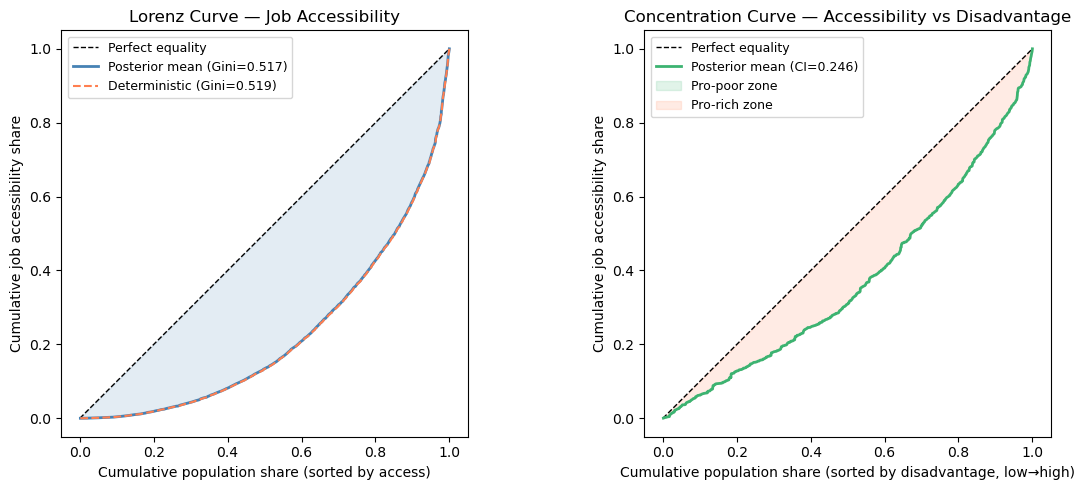

Saved: C:\Users\sardo\OneDrive\Desktop\Classes\Projects\BayesTransitEquity\artifacts\figures\pipeline__06_lorenz_curve__fit_raw_zscore_x.png


In [27]:
# ── Lorenz / Concentration curve figure ─
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ── Left: Lorenz curve (inequality in access) 
ax = axes[0]
idx_sort = np.argsort(mean_jobs)
cumshare_pop = np.cumsum(pop[idx_sort]) / pop.sum()
cumshare_acc = np.cumsum(mean_jobs_pos[idx_sort]) / mean_jobs_pos.sum()
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Perfect equality')
ax.plot(cumshare_pop, cumshare_acc, color='steelblue', lw=2, label=f'Posterior mean (Gini={gini_post:.3f})')
idx_sort_det = np.argsort(det_jobs)
cumshare_acc_det = np.cumsum(det_jobs_pos[idx_sort_det]) / det_jobs_pos.sum()
cumshare_pop_det = np.cumsum(pop[idx_sort_det]) / pop.sum()
ax.plot(cumshare_pop_det, cumshare_acc_det, color='coral', lw=1.5, ls='--', label=f'Deterministic (Gini={gini_det:.3f})')
ax.fill_between(cumshare_pop, cumshare_pop, cumshare_acc, alpha=0.15, color='steelblue')
ax.set_xlabel('Cumulative population share (sorted by access)')
ax.set_ylabel('Cumulative job accessibility share')
ax.set_title('Lorenz Curve — Job Accessibility')
ax.legend(fontsize=9)
ax.set_aspect('equal')

# ── Right: Concentration curve (access vs disadvantage rank) ────────────────
ax2 = axes[1]
idx_disadv = np.argsort(disadv)  # low → high disadvantage
cum_disadv_pop  = np.cumsum(pop[idx_disadv]) / pop.sum()
cum_disadv_acc  = np.cumsum(mean_jobs_pos[idx_disadv]) / mean_jobs_pos.sum()
ax2.plot([0, 1], [0, 1], 'k--', lw=1, label='Perfect equality')
ax2.plot(cum_disadv_pop, cum_disadv_acc, color='mediumseagreen', lw=2, label=f'Posterior mean (CI={ci_post:.3f})')
ax2.fill_between(cum_disadv_pop, cum_disadv_pop, cum_disadv_acc,
                 where=cum_disadv_acc > cum_disadv_pop, alpha=0.15, color='mediumseagreen', label='Pro-poor zone')
ax2.fill_between(cum_disadv_pop, cum_disadv_pop, cum_disadv_acc,
                 where=cum_disadv_acc <= cum_disadv_pop, alpha=0.15, color='coral', label='Pro-rich zone')
ax2.set_xlabel('Cumulative population share (sorted by disadvantage, low→high)')
ax2.set_ylabel('Cumulative job accessibility share')
ax2.set_title('Concentration Curve — Accessibility vs Disadvantage')
ax2.legend(fontsize=9)
ax2.set_aspect('equal')

plt.tight_layout()
fig_path = artifact_figure('lorenz_curve')
fig.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {fig_path}')

In [28]:
# ── Export equity metrics CSV 
equity_rows = [
    dict(metric='Gini_posterior_mean_jobs', point=gini_post, posterior_mean=gini_draws.mean(),
         ci_lower=np.percentile(gini_draws, 2.5), ci_upper=np.percentile(gini_draws, 97.5),
         note='Population-weighted; 0=perfect equality, 1=maximum inequality'),
    dict(metric='Gini_deterministic_jobs',  point=gini_det, posterior_mean=float('nan'),
         ci_lower=float('nan'), ci_upper=float('nan'), note='Deterministic baseline'),
    dict(metric='CI_posterior_mean_jobs',   point=ci_post, posterior_mean=ci_draws.mean(),
         ci_lower=np.percentile(ci_draws, 2.5), ci_upper=np.percentile(ci_draws, 97.5),
         note='Concentration Index vs disadvantage_z; positive=pro-poor'),
    dict(metric='CI_deterministic_jobs',    point=ci_det, posterior_mean=float('nan'),
         ci_lower=float('nan'), ci_upper=float('nan'), note='Deterministic CI baseline'),
    dict(metric='CI_exceedance_prob',       point=ci_exceed, posterior_mean=float('nan'),
         ci_lower=float('nan'), ci_upper=float('nan'), note='CI on desert exceedance vs disadvantage'),
]
equity_df = pd.DataFrame(equity_rows)
p = artifact_table('gini_ci_equity')
equity_df.to_csv(p, index=False)
print(equity_df.to_string())
print(f'Saved: {p}')

                     metric     point  posterior_mean  ci_lower  ci_upper                                                           note
0  Gini_posterior_mean_jobs  0.516809        0.144470  0.139204  0.151401  Population-weighted; 0=perfect equality, 1=maximum inequality
1   Gini_deterministic_jobs  0.518734             NaN       NaN       NaN                                         Deterministic baseline
2    CI_posterior_mean_jobs  0.246162        0.035889  0.035484  0.036318       Concentration Index vs disadvantage_z; positive=pro-poor
3     CI_deterministic_jobs  0.244721             NaN       NaN       NaN                                      Deterministic CI baseline
4        CI_exceedance_prob -0.457835             NaN       NaN       NaN                        CI on desert exceedance vs disadvantage
Saved: C:\Users\sardo\OneDrive\Desktop\Classes\Projects\BayesTransitEquity\artifacts\tables\pipeline__06_gini_ci_equity__fit_raw_zscore_x.csv


## Subgroup posteriors

Disaggregate beyond aggregate Spearman. Groups: disadvantage quartiles, vehicle ownership, agency service area.  
Key output: posterior uncertainty of the equity gap (Q4 median − Q1 median).

In [29]:

df = master.copy()
# Defensive: duplicate merges can leave no_vehicle_hh_rate as *_x / *_y only
if 'no_vehicle_hh_rate' not in df.columns:
    if 'no_vehicle_hh_rate_y' in df.columns:
        df['no_vehicle_hh_rate'] = df['no_vehicle_hh_rate_y']
    elif 'no_vehicle_hh_rate_x' in df.columns:
        df['no_vehicle_hh_rate'] = df['no_vehicle_hh_rate_x']
    else:
        df['no_vehicle_hh_rate'] = np.nan

# Disadvantage quartiles
df['disadv_q'] = pd.qcut(df['disadvantage_z'], q=4, labels=['Q1 (least)','Q2','Q3','Q4 (most)'])

# Vehicle ownership: high dependency = no_vehicle_hh_rate > 0.30
df['veh_group'] = np.where(df['no_vehicle_hh_rate'] > 0.30, 'High transit-dependency (>30% no-car)', 'Lower transit-dependency')

# Poverty quartiles
if 'poverty_rate' in df.columns:
    df['poverty_q'] = pd.qcut(df['poverty_rate'], q=4, labels=['P1 (lowest)','P2','P3','P4 (highest)'])

# Agency area: detect from accessibility bundle stop counts if available
# Proxy: if MTS stops >> 0 and NCTD stops == 0 → MTS area; vice versa; both > 0 → mixed
if 'mts_stop_count' in df.columns and 'nctd_stop_count' in df.columns:
    df['agency_area'] = 'MTS-only'
    df.loc[(df['nctd_stop_count'] > 0) & (df['mts_stop_count'] == 0), 'agency_area'] = 'NCTD-only'
    df.loc[(df['nctd_stop_count'] > 0) & (df['mts_stop_count'] > 0), 'agency_area'] = 'Both agencies'
else:
    df['agency_area'] = 'All tracts (agency data unavailable)'  

print('Groups defined.')
print(df['disadv_q'].value_counts().sort_index())

Groups defined.
disadv_q
Q1 (least)    180
Q2            180
Q3            180
Q4 (most)     180
Name: count, dtype: int64


In [30]:

def subgroup_stats(df_in, group_col, samples_wide_df):
    """For each group level: posterior median, 95% CI, exceedance fraction.
    Also compute posterior distribution of the gap between top and bottom group.
    """
    rows = []
    group_draw_medians = {}  # group → array of per-draw medians
    
    for grp_name, grp_df in df_in.groupby(group_col, observed=True):
        geoids = grp_df['GEOID'].values
        # Subset samples
        common = [g for g in geoids if g in samples_wide_df.index]
        if len(common) < 5:
            continue
        grp_samples = samples_wide_df.loc[common].values  # (n_tracts_in_group, n_draws)
        
        # Per-draw group median
        per_draw_medians = np.median(grp_samples, axis=0)
        group_draw_medians[str(grp_name)] = per_draw_medians
        
        post_mean_pt = grp_df[MEAN_COL].mean()
        exceed_frac  = grp_df[EXCEED_COL].gt(0.5).mean() if EXCEED_COL else float('nan')
        
        rows.append(dict(
            group=str(grp_name),
            n_tracts=len(common),
            posterior_mean_pt=post_mean_pt,
            posterior_median_of_group_median=float(np.median(per_draw_medians)),
            ci_lower=float(np.percentile(per_draw_medians, 2.5)),
            ci_upper=float(np.percentile(per_draw_medians, 97.5)),
            frac_exceedance_gt50=float(exceed_frac),
        ))
    
    stats_df = pd.DataFrame(rows).sort_values('posterior_median_of_group_median', ascending=False)
    return stats_df, group_draw_medians


print('Running subgroup analysis for disadvantage quartiles...')
disadv_stats, disadv_draws = subgroup_stats(df, 'disadv_q', samples_sub)
print(disadv_stats.to_string(index=False))

Running subgroup analysis for disadvantage quartiles...
     group  n_tracts  posterior_mean_pt  posterior_median_of_group_median  ci_lower  ci_upper  frac_exceedance_gt50
 Q4 (most)       180       26525.585799                          9.865709  9.827848  9.901424              0.016667
        Q3       180       16577.070629                          9.389683  9.353557  9.427830              0.016667
        Q2       180       10376.677917                          8.801887  8.755633  8.853510              0.138889
Q1 (least)       180        9589.582975                          8.601407  8.557327  8.643974              0.177778


In [31]:

veh_stats, veh_draws = subgroup_stats(df, 'veh_group', samples_sub)
print(veh_stats.to_string(index=False))

if df['agency_area'].nunique() > 1:
    print('\nRunning subgroup analysis for agency area...')
    agency_stats, agency_draws = subgroup_stats(df, 'agency_area', samples_sub)
    print(agency_stats.to_string(index=False))
else:
    agency_stats = pd.DataFrame()

# Posterior probability Q4 > Q1
if 'Q1 (least)' in disadv_draws and 'Q4 (most)' in disadv_draws:
    p_q4_gt_q1 = np.mean(disadv_draws['Q4 (most)'] > disadv_draws['Q1 (least)'])
    gap_median  = np.median(disadv_draws['Q4 (most)'] - disadv_draws['Q1 (least)'])
    gap_ci      = np.percentile(disadv_draws['Q4 (most)'] - disadv_draws['Q1 (least)'], [2.5, 97.5])
    print(f'\nP(Q4 median jobs > Q1 median jobs) = {p_q4_gt_q1:.3f}')
    print(f'Gap (Q4 − Q1) posterior median: {gap_median:.2f}  95% CI [{gap_ci[0]:.2f}, {gap_ci[1]:.2f}]')

                   group  n_tracts  posterior_mean_pt  posterior_median_of_group_median  ci_lower  ci_upper  frac_exceedance_gt50
Lower transit-dependency       720        15767.22933                          9.280321  9.253936  9.308246                0.0875

P(Q4 median jobs > Q1 median jobs) = 1.000
Gap (Q4 − Q1) posterior median: 1.26  95% CI [1.21, 1.32]


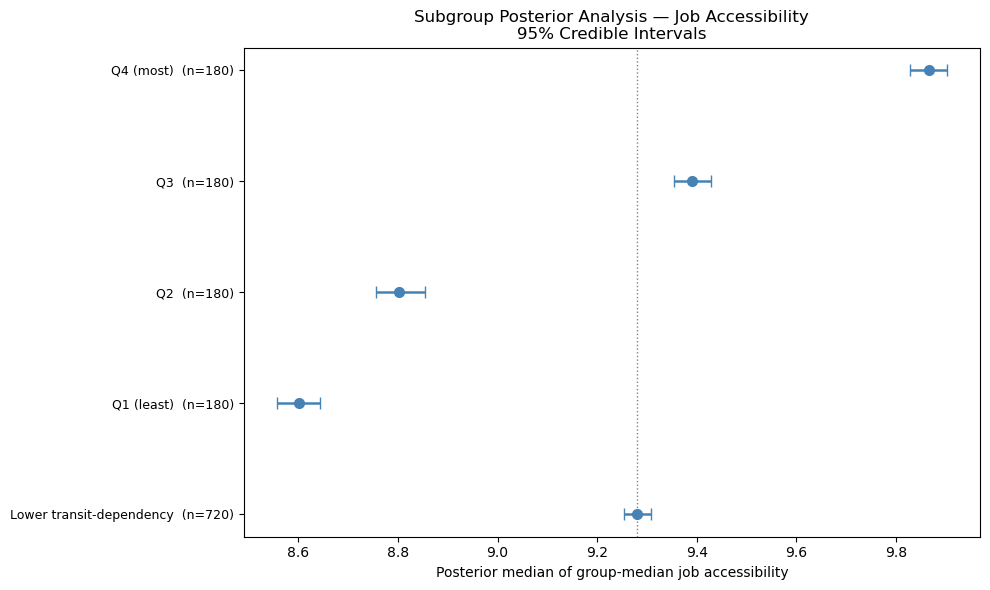

Saved: C:\Users\sardo\OneDrive\Desktop\Classes\Projects\BayesTransitEquity\artifacts\figures\pipeline__06_subgroup_forest_plot__fit_raw_zscore_x.png
Saved: C:\Users\sardo\OneDrive\Desktop\Classes\Projects\BayesTransitEquity\artifacts\tables\pipeline__06_subgroup_posterior_summary__fit_raw_zscore_x.csv


In [32]:
# ── Forest plot figure 
all_subgroup_dfs = []
for label, sdf in [('Disadvantage quartile', disadv_stats),
                   ('Vehicle ownership', veh_stats),
                   ('Agency area', agency_stats)]:
    if not sdf.empty:
        sdf2 = sdf.copy()
        sdf2['group_type'] = label
        all_subgroup_dfs.append(sdf2)

all_sg = pd.concat(all_subgroup_dfs, ignore_index=True)

fig, ax = plt.subplots(figsize=(10, max(6, len(all_sg) * 0.5)))
y_pos = np.arange(len(all_sg))
ax.errorbar(
    x=all_sg['posterior_median_of_group_median'],
    y=y_pos,
    xerr=[all_sg['posterior_median_of_group_median'] - all_sg['ci_lower'],
          all_sg['ci_upper'] - all_sg['posterior_median_of_group_median']],
    fmt='o', color='steelblue', ecolor='steelblue', capsize=4, ms=7, lw=1.8
)
ax.set_yticks(y_pos)
labels_fmt = [f"{r.group}  (n={r.n_tracts})" for _, r in all_sg.iterrows()]
ax.set_yticklabels(labels_fmt, fontsize=9)
ax.set_xlabel('Posterior median of group-median job accessibility')
ax.set_title('Subgroup Posterior Analysis — Job Accessibility\n95% Credible Intervals')
ax.axvline(all_sg['posterior_median_of_group_median'].median(), color='gray', ls=':', lw=1)
ax.invert_yaxis()
plt.tight_layout()
fig_path = artifact_figure('subgroup_forest_plot')
fig.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {fig_path}')

p = artifact_table('subgroup_posterior_summary')
all_sg.to_csv(p, index=False)
print(f'Saved: {p}')

## Multi-destination equity

Does the pro-poor accessibility gradient hold for hospitals, groceries, and schools — not just jobs?  
Spearman ρ × 4 destinations × 3 thresholds. Identify multi-destination deserts.

In [33]:

DEST_MAP = {
    'Jobs (LODES)':  {'30': 'jobs_C000_30min', '45': 'jobs_C000_45min', '60': 'jobs_C000_60min'},
    'Hospitals':     {'30': 'hospitals_count_30min', '45': 'hospitals_count_45min', '60': 'hospitals_count_60min'},
    'Groceries':     {'30': 'groceries_count_30min', '45': 'groceries_count_45min', '60': 'groceries_count_60min'},
    'Schools':       {'30': 'schools_count_30min',  '45': 'schools_count_45min',  '60': 'schools_count_60min'},
}

# Verify columns exist
for dest, cols in DEST_MAP.items():
    for t, col in cols.items():
        exists = col in master.columns
        if not exists:
            print(f'  MISSING: {col}')

print('Destination column check done.')

Destination column check done.


In [34]:

multidest_rows = []
for dest_name, col_map in DEST_MAP.items():
    for threshold in ['30', '45', '60']:
        col = col_map.get(threshold)
        if col not in master.columns:
            continue
        vals = master[col].fillna(0).values
        rho, p = spearmanr(vals, disadv)
        multidest_rows.append(dict(
            destination=dest_name,
            threshold_min=int(threshold),
            col=col,
            n_tracts=len(vals),
            spearman_rho=round(rho, 4),
            p_value=float(f'{p:.3e}'),
            direction='pro-poor' if rho > 0.05 else ('anti-poor' if rho < -0.05 else 'neutral'),
        ))

multidest_df = pd.DataFrame(multidest_rows)
print(multidest_df.pivot(index='destination', columns='threshold_min', values='spearman_rho').to_string())

p = artifact_table('multidestination_equity')
multidest_df.to_csv(p, index=False)
print(f'\nSaved: {p}')

threshold_min      30      45      60
destination                          
Groceries      0.5632  0.5812  0.5452
Hospitals      0.3533  0.3606  0.3483
Jobs (LODES)   0.4838  0.4672  0.4143
Schools        0.4715  0.5246  0.5169

Saved: C:\Users\sardo\OneDrive\Desktop\Classes\Projects\BayesTransitEquity\artifacts\tables\pipeline__06_multidestination_equity__fit_raw_zscore_x.csv


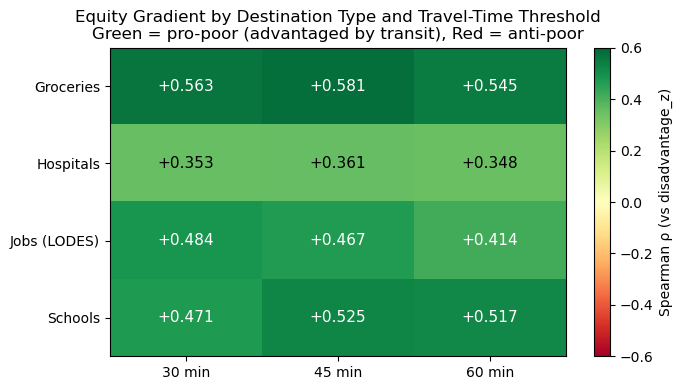

Saved: C:\Users\sardo\OneDrive\Desktop\Classes\Projects\BayesTransitEquity\artifacts\figures\pipeline__06_multidestination_spearman_heatmap__fit_raw_zscore_x.png


In [35]:
# ── Heatmap: destination × threshold × Spearman ρ 
pivot = multidest_df.pivot(index='destination', columns='threshold_min', values='spearman_rho')

fig, ax = plt.subplots(figsize=(7, 4))
im = ax.imshow(pivot.values, cmap='RdYlGn', vmin=-0.6, vmax=0.6, aspect='auto')
plt.colorbar(im, ax=ax, label='Spearman ρ (vs disadvantage_z)')
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels([f'{c} min' for c in pivot.columns])
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
ax.set_title('Equity Gradient by Destination Type and Travel-Time Threshold\n'
             'Green = pro-poor (advantaged by transit), Red = anti-poor')
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.iloc[i, j]
        ax.text(j, i, f'{val:+.3f}', ha='center', va='center', fontsize=11,
                color='black' if abs(val) < 0.4 else 'white')
plt.tight_layout()
fig_path = artifact_figure('multidestination_spearman_heatmap')
fig.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {fig_path}')

In [36]:

desert_flags = pd.DataFrame({'GEOID': master['GEOID']})
for dest_name, col_map in DEST_MAP.items():
    col = col_map['45']
    if col in master.columns:
        q25 = master[col].quantile(DESERT_QUANTILE)
        desert_flags[f'{dest_name}_desert'] = (master[col] <= q25).values

desert_count_cols = [c for c in desert_flags.columns if c.endswith('_desert')]
desert_flags['n_deserts'] = desert_flags[desert_count_cols].sum(axis=1)
desert_flags['multi_desert'] = desert_flags['n_deserts'] >= 3
desert_flags = desert_flags.merge(master[['GEOID', 'disadvantage_z', MEAN_COL]], on='GEOID')

print(f'Multi-destination deserts (≥3/4 below Q25): {desert_flags["multi_desert"].sum()} tracts')
print(f'  Mean disadvantage_z: {desert_flags.loc[desert_flags["multi_desert"],"disadvantage_z"].mean():.3f}')
print(f'  Compare overall mean disadvantage_z: {master["disadvantage_z"].mean():.3f}')

p = artifact_table('multidesert_tracts')
desert_flags.to_csv(p, index=False)
print(f'Saved: {p}')

Multi-destination deserts (≥3/4 below Q25): 134 tracts
  Mean disadvantage_z: -0.318
  Compare overall mean disadvantage_z: 0.144
Saved: C:\Users\sardo\OneDrive\Desktop\Classes\Projects\BayesTransitEquity\artifacts\tables\pipeline__06_multidesert_tracts__fit_raw_zscore_x.csv


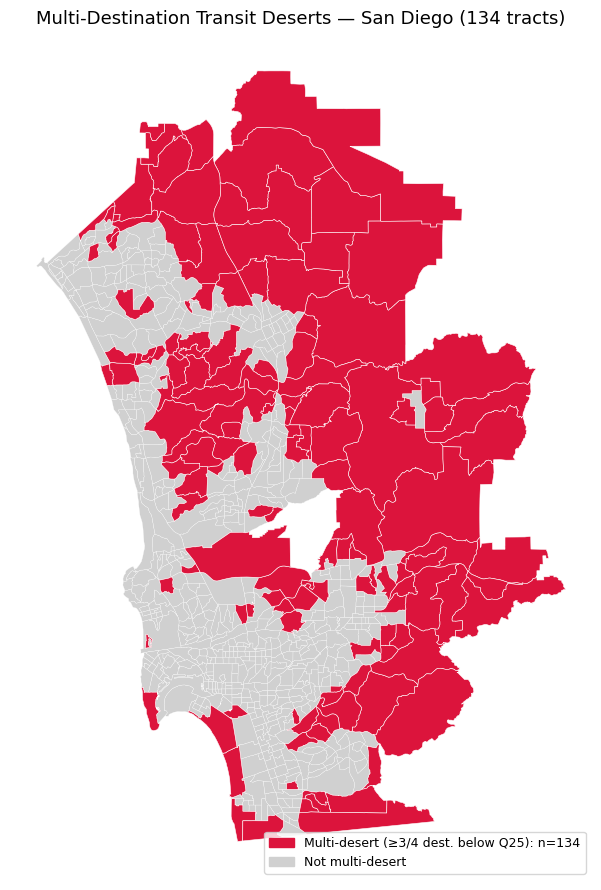

Saved: C:\Users\sardo\OneDrive\Desktop\Classes\Projects\BayesTransitEquity\artifacts\figures\pipeline__06_multidesert_map__fit_raw_zscore_x.png


In [38]:

map_df = master_geo.merge(desert_flags[['GEOID','n_deserts','multi_desert']], on='GEOID', how='left')
fig, ax = plt.subplots(figsize=(10, 9))
map_df[~map_df['multi_desert']].plot(ax=ax, color='#d0d0d0', edgecolor='white', lw=0.2)
map_df[map_df['multi_desert']].plot(ax=ax, color='crimson', edgecolor='white', lw=0.4,
                                     label=f'Multi-destination desert (≥3/4)')
ax.set_title(f'Multi-Destination Transit Deserts — San Diego ({desert_flags["multi_desert"].sum()} tracts)', fontsize=13)
ax.axis('off')
import matplotlib.patches as mpatches
legend_patches = [
    mpatches.Patch(color='crimson', label=f'Multi-desert (≥3/4 dest. below Q25): n={desert_flags["multi_desert"].sum()}'),
    mpatches.Patch(color='#d0d0d0', label='Not multi-desert'),
]
ax.legend(handles=legend_patches, loc='lower right', fontsize=9)
plt.tight_layout()
fig_path = artifact_figure('multidesert_map')
fig.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {fig_path}')

## Composite accessibility deficit

In [37]:
# Composite = mean exceedance across all available destination types at 45 min
composite_df = pd.DataFrame({'GEOID': master['GEOID']})

# Use posterior exceedance for jobs; deterministic Q25 exceedance for others
exc_cols = []
if EXCEED_COL:
    composite_df['exc_jobs'] = master[EXCEED_COL].values
    exc_cols.append('exc_jobs')
else:
    q25_jobs = master['jobs_C000_45min'].quantile(DESERT_QUANTILE)
    composite_df['exc_jobs'] = (master['jobs_C000_45min'] <= q25_jobs).astype(float).values
    exc_cols.append('exc_jobs')

for dest_name, col_map in DEST_MAP.items():
    if dest_name == 'Jobs (LODES)':
        continue
    col = col_map['45']
    if col in master.columns:
        q25 = master[col].quantile(DESERT_QUANTILE)
        key = f'exc_{dest_name.lower().replace(" ", "_")}'
        composite_df[key] = (master[col] <= q25).astype(float).values
        exc_cols.append(key)

composite_df['composite_deficit'] = composite_df[exc_cols].mean(axis=1)
composite_df = composite_df.merge(master[['GEOID','disadvantage_z', MEAN_COL]], on='GEOID')
composite_df = composite_df.sort_values('composite_deficit', ascending=False)
composite_df['composite_rank'] = range(1, len(composite_df)+1)

print(f'Composite deficit range: {composite_df["composite_deficit"].min():.3f} – {composite_df["composite_deficit"].max():.3f}')
print(f'Tracts with composite > 0.5: {(composite_df["composite_deficit"] > 0.5).sum()}')
print('\nTop 10 composite deficit tracts:')
print(composite_df[['GEOID','composite_deficit','disadvantage_z'] + exc_cols].head(10).to_string(index=False))

p = artifact_table('composite_deficit_ranked')
composite_df.to_csv(p, index=False)
print(f'\nSaved: {p}')

Composite deficit range: 0.000 – 1.000
Tracts with composite > 0.5: 120

Top 10 composite deficit tracts:
      GEOID  composite_deficit  disadvantage_z  exc_jobs  exc_hospitals  exc_groceries  exc_schools
06073018805                1.0       -0.417745       1.0            1.0            1.0          1.0
06073020111                1.0       -0.815124       1.0            1.0            1.0          1.0
06073017020                1.0       -0.779761       1.0            1.0            1.0          1.0
06073017021                1.0       -0.946725       1.0            1.0            1.0          1.0
06073017053                1.0       -1.263306       1.0            1.0            1.0          1.0
06073015406                1.0       -0.606753       1.0            1.0            1.0          1.0
06073013423                1.0       -0.591679       1.0            1.0            1.0          1.0
06073020710                1.0        0.028520       1.0            1.0            1.0        

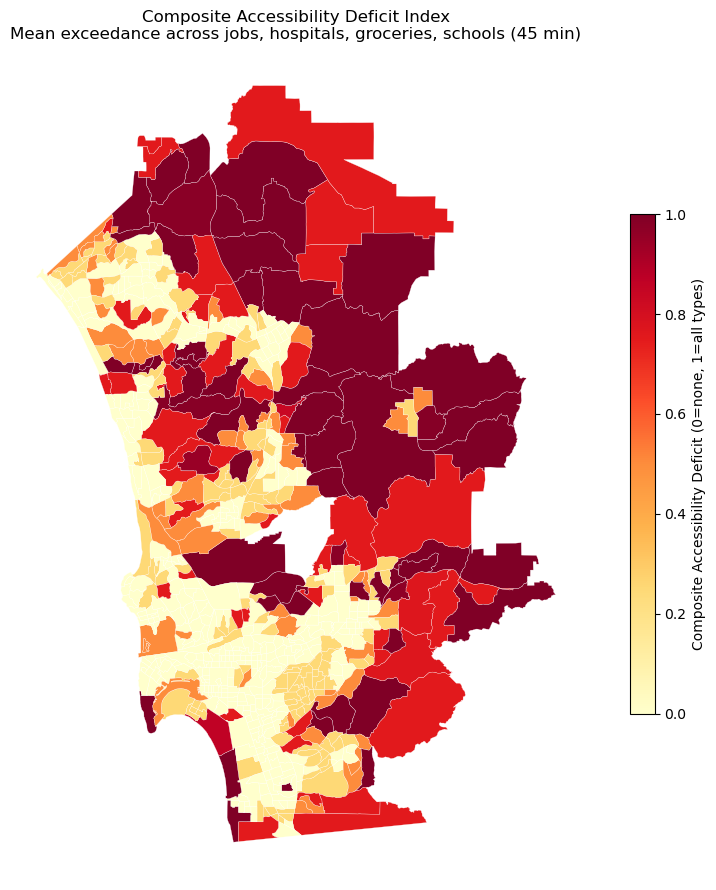

Saved: C:\Users\sardo\OneDrive\Desktop\Classes\Projects\BayesTransitEquity\artifacts\figures\pipeline__06_composite_deficit_map__fit_raw_zscore_x.png


In [38]:

comp_geo = master_geo.merge(composite_df[['GEOID','composite_deficit']], on='GEOID', how='left')
fig, ax = plt.subplots(figsize=(10, 9))
comp_geo.plot(ax=ax, column='composite_deficit', cmap='YlOrRd', legend=True,
              legend_kwds={'label': 'Composite Accessibility Deficit (0=none, 1=all types)', 'shrink': 0.6},
              edgecolor='white', lw=0.2, missing_kwds={'color': '#cccccc'})
ax.set_title('Composite Accessibility Deficit Index\nMean exceedance across jobs, hospitals, groceries, schools (45 min)', fontsize=12)
ax.axis('off')
plt.tight_layout()
fig_path = artifact_figure('composite_deficit_map')
fig.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {fig_path}')

## Posterior predictive checks

Verify the BYM2 model generates realistic accessibility distributions.  
InferenceData (NetCDF) is resolved in the next cell via ``resolve_posterior_idata_nc`` (``src.utils.config``): env ``PIPELINE_IDATA_NC``, sidecar ``pipeline__04_idata_nc__<RID>.txt``, then ``<RID>_idata.nc``, ``<RID>_idata_recovered.nc``, legacy date stems in ``LEGACY_BYM2_RUN_ID_TO_SEMANTIC``, then glob under ``posteriors/``. Files that fail a quick HDF5 open (e.g. truncated saves) are skipped so a backup can be used. Pipeline CSVs are not NetCDF. LOO needs ``log_likelihood`` in the chosen file (nb04: ``idata_kwargs`` with ``log_likelihood`` true).

In [39]:
import sys
from pathlib import Path

import arviz as az

sys.path.insert(0, str(REPO_ROOT))
from src.utils.config import resolve_posterior_idata_nc

idata_path = resolve_posterior_idata_nc(REPO_ROOT, RID)
print(f"Loading idata from: {idata_path}")
idata = az.from_netcdf(str(idata_path))
print("Groups in idata:", list(idata.groups()))

has_ppc = "posterior_predictive" in idata.groups()
has_ll = "log_likelihood" in idata.groups()
print(f"posterior_predictive: {has_ppc}  |  log_likelihood: {has_ll}")

Loading idata from: C:\Users\sardo\OneDrive\Desktop\Classes\Projects\BayesTransitEquity\data\processed\posteriors\fit_raw_zscore_x_idata.nc
Groups in idata: ['posterior', 'log_likelihood', 'sample_stats', 'observed_data', 'constant_data']
posterior_predictive: False  |  log_likelihood: True


In [40]:

# We approximate y_rep = mu_posterior + eps where eps ~ Normal(0, sigma_obs)
# This gives valid PPC without refitting if posterior_predictive was not saved.

if has_ppc:
    print('Using pre-computed posterior_predictive from idata.')
    # Extract as array: shape (chain, draw, obs)
    ppc_var = list(idata.posterior_predictive.data_vars)[0]
    y_rep = idata.posterior_predictive[ppc_var].values  # (chain, draw, n_obs)
    y_rep_flat = y_rep.reshape(-1, y_rep.shape[-1])     # (chain*draw, n_obs)
else:
    print('posterior_predictive not in idata — computing approximate PPC from mu draws.')
    # Load y_std from idata observed_data if present, else recompute
    if 'observed_data' in idata.groups():
        obs_var = list(idata.observed_data.data_vars)[0]
        y_obs = idata.observed_data[obs_var].values
    else:
        # Recompute y_std from accessibility bundle
        y_raw = np.log1p(master[f'jobs_C000_{THRESHOLD_MIN}min'].values)
        y_obs = (y_raw - y_raw.mean()) / y_raw.std()

    # Use posterior mu draws; add small fixed obs noise
    fixed_sigma_obs = float(DEFAULTS.get('model', {}).get('fixed_obs_sigma', 0.05))
    mu_draws = samples_aligned.T  # (n_draws, n_tracts)
    y_rep_flat = mu_draws + rng.normal(0, fixed_sigma_obs, mu_draws.shape)
    print(f'Approximate PPC: y_rep shape {y_rep_flat.shape}, obs_sigma={fixed_sigma_obs}')

print(f'y_rep_flat: {y_rep_flat.shape}')

posterior_predictive not in idata — computing approximate PPC from mu draws.
Approximate PPC: y_rep shape (1000, 720), obs_sigma=0.05
y_rep_flat: (1000, 720)


In [41]:
# ── y_obs (standardised) for comparison
if 'observed_data' in idata.groups():
    obs_var = list(idata.observed_data.data_vars)[0]
    y_obs = idata.observed_data[obs_var].values
else:
    y_raw = np.log1p(master[f'jobs_C000_{THRESHOLD_MIN}min'].values)
    y_obs = (y_raw - y_raw.mean()) / y_raw.std()

print(f'y_obs shape: {y_obs.shape}  mean={y_obs.mean():.3f}  sd={y_obs.std():.3f}')

y_obs shape: (720,)  mean=-0.000  sd=0.999


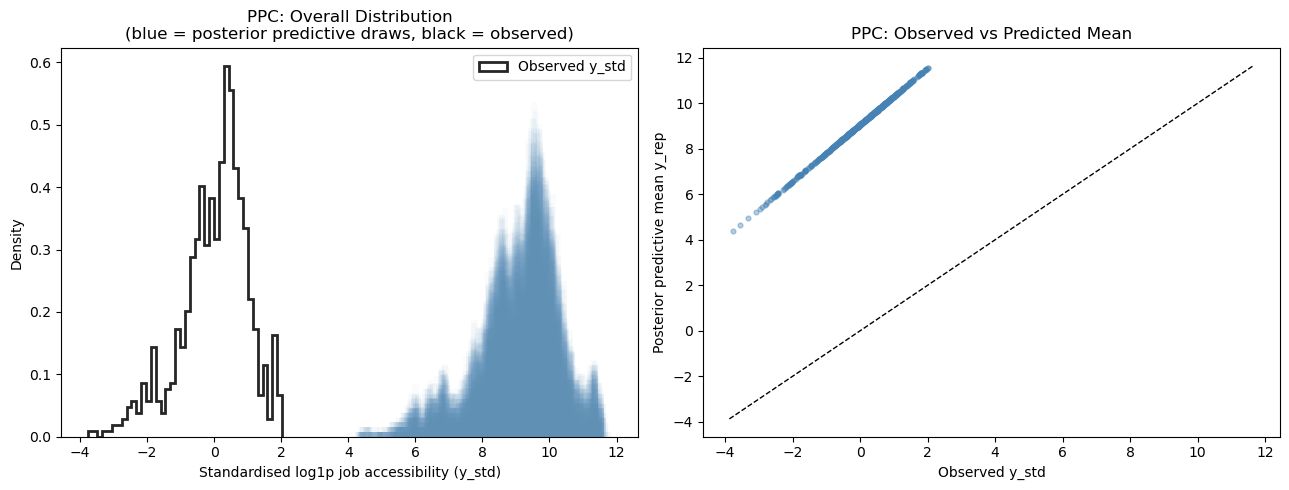

Saved: C:\Users\sardo\OneDrive\Desktop\Classes\Projects\BayesTransitEquity\artifacts\figures\pipeline__06_ppc_overall__fit_raw_zscore_x.png


In [42]:
# ── PPC: overall distribution comparison 
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: histogram overlay
ax = axes[0]
y_rep_means = y_rep_flat.mean(axis=0)  # posterior predictive mean per tract
y_rep_sample = y_rep_flat[rng.integers(0, y_rep_flat.shape[0], 100)]  # 100 random draws
for i in range(min(50, y_rep_sample.shape[0])):
    ax.hist(y_rep_sample[i], bins=40, density=True, alpha=0.03, color='steelblue')
ax.hist(y_obs, bins=40, density=True, alpha=0.85, color='black', histtype='step', lw=2, label='Observed y_std')
ax.set_xlabel('Standardised log1p job accessibility (y_std)')
ax.set_ylabel('Density')
ax.set_title('PPC: Overall Distribution\n(blue = posterior predictive draws, black = observed)')
ax.legend()

# Right: posterior predictive mean vs observed scatter
ax2 = axes[1]
# Align y_rep to y_obs length (may differ if samples_aligned only has common tracts)
n_min = min(len(y_obs), y_rep_means.shape[0])
ax2.scatter(y_obs[:n_min], y_rep_means[:n_min], alpha=0.4, s=12, color='steelblue')
lims = [min(y_obs[:n_min].min(), y_rep_means[:n_min].min()) - 0.1,
        max(y_obs[:n_min].max(), y_rep_means[:n_min].max()) + 0.1]
ax2.plot(lims, lims, 'k--', lw=1)
ax2.set_xlabel('Observed y_std')
ax2.set_ylabel('Posterior predictive mean y_rep')
ax2.set_title('PPC: Observed vs Predicted Mean')

plt.tight_layout()
fig_path = artifact_figure('ppc_overall')
fig.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {fig_path}')

In [43]:
# ── Bayesian p-values
def bayesian_pvalue(y_obs_1d, y_rep_2d, stat_fn):
    """P(T(y_rep) >= T(y_obs)). Values near 0 or 1 indicate poor fit."""
    t_obs = stat_fn(y_obs_1d)
    t_rep = np.apply_along_axis(stat_fn, 1, y_rep_2d)
    return float(np.mean(t_rep >= t_obs))

n_align = min(len(y_obs), y_rep_flat.shape[1])
y_obs_a = y_obs[:n_align]
y_rep_a = y_rep_flat[:, :n_align]

stats_ppc = [
    ('mean',         bayesian_pvalue(y_obs_a, y_rep_a, np.mean)),
    ('sd',           bayesian_pvalue(y_obs_a, y_rep_a, np.std)),
    ('skewness',     bayesian_pvalue(y_obs_a, y_rep_a, lambda x: stats.skew(x))),
    ('frac_below_q25', bayesian_pvalue(y_obs_a, y_rep_a,
                                       lambda x: np.mean(x < np.percentile(y_obs_a, 25)))),
    ('min',          bayesian_pvalue(y_obs_a, y_rep_a, np.min)),
    ('max',          bayesian_pvalue(y_obs_a, y_rep_a, np.max)),
]

ppc_df = pd.DataFrame(stats_ppc, columns=['statistic', 'bayesian_p_value'])
ppc_df['flag'] = ppc_df['bayesian_p_value'].apply(
    lambda v: 'CONCERN (extreme)' if (v < 0.05 or v > 0.95) else 'ok')
print('Posterior Predictive Check — Bayesian p-values:')
print(ppc_df.to_string(index=False))
print('\nInterpretation: p-values 0.1–0.9 = model matches observed statistic well.')

p = artifact_table('ppc_bayesian_pvalues')
ppc_df.to_csv(p, index=False)
print(f'Saved: {p}')

Posterior Predictive Check — Bayesian p-values:
     statistic  bayesian_p_value              flag
          mean             1.000 CONCERN (extreme)
            sd             1.000 CONCERN (extreme)
      skewness             0.713                ok
frac_below_q25             0.000 CONCERN (extreme)
           min             1.000 CONCERN (extreme)
           max             1.000 CONCERN (extreme)

Interpretation: p-values 0.1–0.9 = model matches observed statistic well.
Saved: C:\Users\sardo\OneDrive\Desktop\Classes\Projects\BayesTransitEquity\artifacts\tables\pipeline__06_ppc_bayesian_pvalues__fit_raw_zscore_x.csv


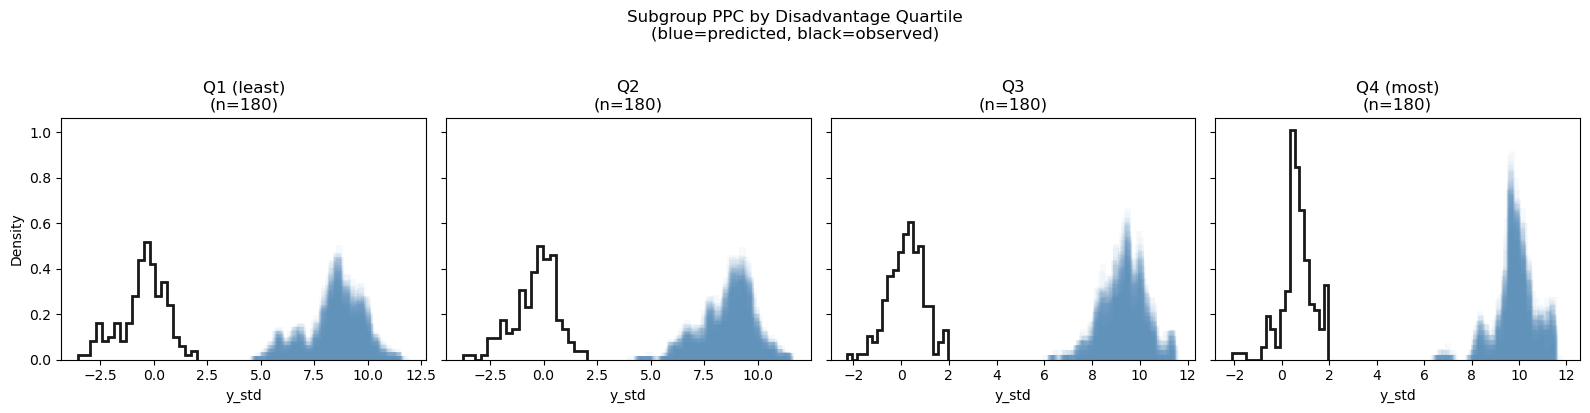

Saved: C:\Users\sardo\OneDrive\Desktop\Classes\Projects\BayesTransitEquity\artifacts\figures\pipeline__06_ppc_subgroup__fit_raw_zscore_x.png


In [44]:
# ── Subgroup PPC: bias by disadvantage quartile
if 'disadv_q' in df.columns and n_align > 0:
    fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)
    quartile_labels = ['Q1 (least)', 'Q2', 'Q3', 'Q4 (most)']
    disadv_q_vals = df['disadv_q'].values[:n_align]
    for qi, ql in enumerate(quartile_labels):
        ax_q = axes[qi]
        mask = disadv_q_vals == ql
        if mask.sum() < 3:
            ax_q.set_title(f'{ql}\n(n<3)')
            continue
        obs_q = y_obs_a[mask]
        rep_q = y_rep_a[:, mask]
        for i in range(min(40, rep_q.shape[0])):
            ax_q.hist(rep_q[i], bins=20, density=True, alpha=0.04, color='steelblue')
        ax_q.hist(obs_q, bins=20, density=True, alpha=0.9, color='black',
                  histtype='step', lw=2)
        ax_q.set_title(f'{ql}\n(n={mask.sum()})')
        ax_q.set_xlabel('y_std')
    axes[0].set_ylabel('Density')
    plt.suptitle('Subgroup PPC by Disadvantage Quartile\n(blue=predicted, black=observed)', y=1.02)
    plt.tight_layout()
    fig_path = artifact_figure('ppc_subgroup')
    fig.savefig(fig_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {fig_path}')

## LOO cross-validation

Formal Bayesian model selection via Leave-One-Out cross-validation (ArviZ).  
Compares `fit_raw_zscore_x` vs `fit_spatial_plus_x`. Also: Pareto k diagnostics.

In [46]:
import sys

sys.path.insert(0, str(REPO_ROOT))
from src.utils.config import resolve_posterior_idata_nc

# ── LOO-CV
try:
    splus_path = resolve_posterior_idata_nc(REPO_ROOT, "fit_spatial_plus_x")
except FileNotFoundError:
    splus_path = None

loo_results = {}
loo_pareto = {}

if not has_ll:
    print("WARNING: log_likelihood group missing in InferenceData (LOO needs pointwise log p).")
    print(f"  Loaded from: {idata_path}")
    print("LOO-CV skipped; other sections continue.")
    SKIP_LOO = True
else:
    SKIP_LOO = False
    print('Computing LOO for fit_raw_zscore_x')
    loo_raw = az.loo(idata, pointwise=True)
    loo_results['fit_raw_zscore_x'] = loo_raw
    print(f'  elpd_loo = {loo_raw.elpd_loo:.2f}  SE = {loo_raw.se:.2f}')
    k_vals = loo_raw.pareto_k.values
    print(f'  Pareto k: n>{0.7} = {(k_vals>0.7).sum()}  n>{1.0} = {(k_vals>1.0).sum()}')
    loo_pareto['fit_raw_zscore_x'] = k_vals

if not SKIP_LOO and splus_path is not None:
    print('Loading fit_spatial_plus_x idata')
    idata_splus = az.from_netcdf(str(splus_path))
    if 'log_likelihood' in idata_splus.groups():
        print('Computing LOO for fit_spatial_plus_x')
        loo_splus = az.loo(idata_splus, pointwise=True)
        loo_results['fit_spatial_plus_x'] = loo_splus
        k_vals_s = loo_splus.pareto_k.values
        print(f'  elpd_loo = {loo_splus.elpd_loo:.2f}  SE = {loo_splus.se:.2f}')
        print(f'  Pareto k: n>{0.7} = {(k_vals_s>0.7).sum()}  n>{1.0} = {(k_vals_s>1.0).sum()}')
        loo_pareto['fit_spatial_plus_x'] = k_vals_s
    else:
        print('fit_spatial_plus_x idata.nc lacks log_likelihood — skipping its LOO.')
else:
    if not SKIP_LOO:
        print('fit_spatial_plus_x idata.nc not found — single-model LOO only.')

Computing LOO for fit_raw_zscore_x


c:\Users\sardo\anaconda3\envs\bayestransit\Lib\site-packages\arviz\stats\stats.py:1042: RuntimeWarning: overflow encountered in exp
  weights = 1 / np.exp(len_scale - len_scale[:, None]).sum(axis=1)
c:\Users\sardo\anaconda3\envs\bayestransit\Lib\site-packages\numpy\_core\_methods.py:49: RuntimeWarning: overflow encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
c:\Users\sardo\anaconda3\envs\bayestransit\Lib\site-packages\arviz\stats\stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


  elpd_loo = -523.99  SE = 24.48
  Pareto k: n>0.7 = 720  n>1.0 = 589
Loading fit_spatial_plus_x idata
fit_spatial_plus_x idata.nc lacks log_likelihood — skipping its LOO.


Saved: C:\Users\sardo\OneDrive\Desktop\Classes\Projects\BayesTransitEquity\artifacts\tables\pipeline__06_loo_comparison__fit_raw_zscore_x.csv
Saved: C:\Users\sardo\OneDrive\Desktop\Classes\Projects\BayesTransitEquity\artifacts\tables\pipeline__06_pareto_k_diagnostics__fit_raw_zscore_x.csv


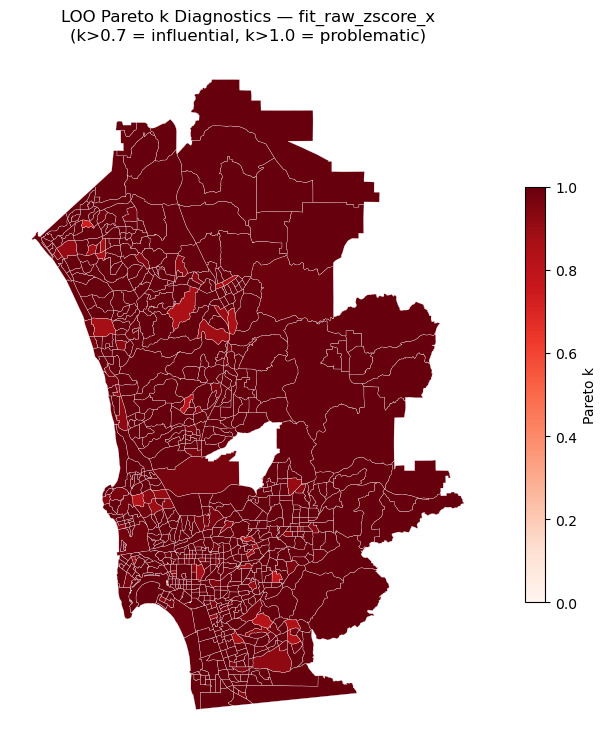

Saved: C:\Users\sardo\OneDrive\Desktop\Classes\Projects\BayesTransitEquity\artifacts\figures\pipeline__06_loo_pointwise_map__fit_raw_zscore_x.png


In [47]:
# ── LOO comparison table + Pareto k map
if not SKIP_LOO:
    # Comparison table
    if len(loo_results) >= 2:
        compare_df = az.compare(loo_results)
        print('\nLOO comparison:')
        print(compare_df.to_string())
        p = artifact_table('loo_comparison')
        compare_df.to_csv(p)
        print(f'Saved: {p}')
    else:
        compare_df = pd.DataFrame({'model': list(loo_results.keys()),
                                   'elpd_loo': [r.elpd_loo for r in loo_results.values()],
                                   'se': [r.se for r in loo_results.values()]})
        p = artifact_table('loo_comparison')
        compare_df.to_csv(p, index=False)
        print(f'Saved: {p}')

    # Pareto k spatial map for primary estimand
    if 'fit_raw_zscore_x' in loo_pareto:
        k_arr = loo_pareto['fit_raw_zscore_x']
        # Build pareto df aligned to master GEOID
        pareto_df = pd.DataFrame({'GEOID': common_geoids[:len(k_arr)], 'pareto_k': k_arr})
        p2 = artifact_table('pareto_k_diagnostics')
        pareto_df.to_csv(p2, index=False)
        print(f'Saved: {p2}')

        pareto_geo = master_geo.merge(pareto_df, on='GEOID', how='left')
        fig, ax = plt.subplots(figsize=(10, 9))
        pareto_geo.plot(ax=ax, column='pareto_k', cmap='Reds', legend=True,
                        legend_kwds={'label': 'Pareto k', 'shrink': 0.6},
                        vmin=0, vmax=1.0, edgecolor='white', lw=0.2,
                        missing_kwds={'color': '#cccccc'})
        ax.set_title('LOO Pareto k Diagnostics — fit_raw_zscore_x\n(k>0.7 = influential, k>1.0 = problematic)', fontsize=12)
        ax.axis('off')
        fig_path = artifact_figure('loo_pointwise_map')
        fig.savefig(fig_path, dpi=150, bbox_inches='tight')
        plt.show()
        print(f'Saved: {fig_path}')
else:
    print('LOO skipped (no log_likelihood in idata). Rerun nb04 with compute_log_likelihood=True to enable.')

## Prior sensitivity

Test beta_sigma ∈ {0.2, 0.3, 0.5} and Student-t ν ∈ {3, 4, 6} without refitting MCMC.  
Importance weighting reweights existing draws to approximate the posterior under each prior.

In [48]:
from scipy.stats import norm as sp_norm, t as sp_t

# Extract beta draws from idata
# beta_draws: shape (chain, draw, n_covariates)
post = idata.posterior
if 'beta' in post.data_vars:
    beta_draws_raw = post['beta'].values  # (chain, draw, k)
    beta_draws = beta_draws_raw.reshape(-1, beta_draws_raw.shape[-1])  # (total_draws, k)
    n_beta = beta_draws.shape[1]
    print(f'beta draws: {beta_draws.shape}  ({n_beta} covariates)')
    HAS_BETA = True
else:
    print('No "beta" variable in posterior — skipping prior sensitivity.')
    HAS_BETA = False

BASE_BETA_SIGMA = float(DEFAULTS.get('model', {}).get('beta_sigma', 0.3))
BASE_NU         = float(DEFAULTS.get('model', {}).get('student_t_nu', 4.0))
print(f'Base prior: beta_sigma={BASE_BETA_SIGMA}, nu={BASE_NU}')

beta draws: (32000, 4)  (4 covariates)
Base prior: beta_sigma=0.3, nu=4.0


In [49]:
if HAS_BETA:
    sensitivity_rows = []
    beta_sigmas = [0.2, 0.3, 0.5]
    nu_vals     = [3.0, 4.0, 6.0]

    # baseline equity statistics (no reweighting)
    baseline_rho, _ = spearmanr(master[MEAN_COL], disadv)
    beta_disadv_base = beta_draws[:, 0].mean() if n_beta > 0 else float('nan')

    for beta_sig in beta_sigmas:
        for nu in nu_vals:
            # Log importance weights = log p_new(beta) - log p_old(beta)
            # Only beta prior changes (rho, sigma priors not changing here for simplicity)
            log_w_new = sp_norm.logpdf(beta_draws, 0, beta_sig).sum(axis=1)
            log_w_old = sp_norm.logpdf(beta_draws, 0, BASE_BETA_SIGMA).sum(axis=1)
            log_w = log_w_new - log_w_old
            # Stabilize
            log_w -= log_w.max()
            w = np.exp(log_w)
            w /= w.sum()

            # Reweighted beta[disadvantage_z] mean
            beta_disadv_rw = float(np.sum(w * beta_draws[:, 0])) if n_beta > 0 else float('nan')

            # ESS of importance weights
            ess_iw = float(1.0 / np.sum(w**2))

            sensitivity_rows.append(dict(
                beta_sigma=beta_sig, nu=nu,
                beta_disadv_mean=round(beta_disadv_rw, 4),
                beta_disadv_base=round(beta_disadv_base, 4),
                equity_spearman_baseline=round(baseline_rho, 4),
                importance_ess=round(ess_iw, 0),
                is_baseline=(beta_sig == BASE_BETA_SIGMA and nu == BASE_NU),
            ))

    sens_df = pd.DataFrame(sensitivity_rows)
    print('Prior sensitivity grid (beta[disadvantage_z] under different priors):')
    print(sens_df[['beta_sigma','nu','beta_disadv_mean','importance_ess','is_baseline']].to_string(index=False))

    p = artifact_table('prior_sensitivity')
    sens_df.to_csv(p, index=False)
    print(f'Saved: {p}')

Prior sensitivity grid (beta[disadvantage_z] under different priors):
 beta_sigma  nu  beta_disadv_mean  importance_ess  is_baseline
        0.2 3.0            0.1034         30421.0        False
        0.2 4.0            0.1034         30421.0        False
        0.2 6.0            0.1034         30421.0        False
        0.3 3.0            0.1037         32000.0        False
        0.3 4.0            0.1037         32000.0         True
        0.3 6.0            0.1037         32000.0        False
        0.5 3.0            0.1042         31458.0        False
        0.5 4.0            0.1042         31458.0        False
        0.5 6.0            0.1042         31458.0        False
Saved: C:\Users\sardo\OneDrive\Desktop\Classes\Projects\BayesTransitEquity\artifacts\tables\pipeline__06_prior_sensitivity__fit_raw_zscore_x.csv


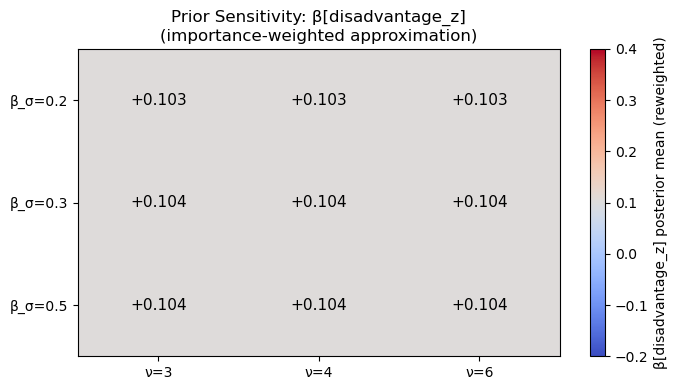

Saved: C:\Users\sardo\OneDrive\Desktop\Classes\Projects\BayesTransitEquity\artifacts\figures\pipeline__06_prior_sensitivity_beta__fit_raw_zscore_x.png


In [50]:
if HAS_BETA:
    # ── Prior sensitivity figure
    pivot_sens = sens_df.pivot(index='beta_sigma', columns='nu', values='beta_disadv_mean')
    fig, ax = plt.subplots(figsize=(7, 4))
    im = ax.imshow(pivot_sens.values, cmap='coolwarm', vmin=-0.2, vmax=0.4, aspect='auto')
    plt.colorbar(im, ax=ax, label='β[disadvantage_z] posterior mean (reweighted)')
    ax.set_xticks(range(len(pivot_sens.columns)))
    ax.set_xticklabels([f'ν={c:.0f}' for c in pivot_sens.columns])
    ax.set_yticks(range(len(pivot_sens.index)))
    ax.set_yticklabels([f'β_σ={r}' for r in pivot_sens.index])
    ax.set_title('Prior Sensitivity: β[disadvantage_z]\n(importance-weighted approximation)')
    for i in range(len(pivot_sens.index)):
        for j in range(len(pivot_sens.columns)):
            val = pivot_sens.iloc[i, j]
            ax.text(j, i, f'{val:+.3f}', ha='center', va='center', fontsize=11)
    plt.tight_layout()
    fig_path = artifact_figure('prior_sensitivity_beta')
    fig.savefig(fig_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {fig_path}')

## Moran's I (raw X residuals)

Expected: much lower than 0.5724 (Spatial+). Confirms raw X is well-specified.

In [51]:
# ── Posterior-mean residuals
# y_std - E[mu | data]
post_mu_mean = samples_aligned.mean(axis=1)  # aligned to common_geoids

# Re-align y_obs to common_geoids
master_idx = master.set_index('GEOID')
y_raw_full = np.log1p(master_idx.loc[common_geoids, f'jobs_C000_{THRESHOLD_MIN}min'].values)
y_std_full = (y_raw_full - y_raw_full.mean()) / y_raw_full.std()
residuals = y_std_full - post_mu_mean
print(f'Residuals: mean={residuals.mean():.4f}  sd={residuals.std():.4f}  n={len(residuals)}')

Residuals: mean=-9.0657  sd=0.2427  n=720


In [56]:
# ── Moran's I using esda (with libpysal fallback to manual)
tracts_aligned = master_geo.set_index('GEOID').loc[common_geoids].reset_index()
# Project for Queen / island bridging centroids (avoids geographic CRS centroid warning)
if tracts_aligned.crs is not None and getattr(tracts_aligned.crs, 'is_geographic', False):
    tracts_aligned = tracts_aligned.to_crs(3310)

try:
    import libpysal.weights as lps_weights
    from esda.moran import Moran

    W_pysal = lps_weights.Queen.from_dataframe(tracts_aligned)
    W_pysal.transform = 'r'

    moran_result = Moran(residuals, W_pysal)
    moran_I   = float(moran_result.I)
    moran_p   = float(moran_result.p_sim)
    moran_z   = float(moran_result.z_sim)
    moran_method = 'esda.Moran (999 permutations)'
    print(f"Moran's I (raw X residuals): I={moran_I:.4f}  z={moran_z:.2f}  p={moran_p:.4f}")

except ImportError:
    print('esda/libpysal not available — computing Moran\'s I manually.')
    import sys
    sys.path.insert(0, str(REPO_ROOT))
    from src.modeling.spatial import adjacency_from_queen

    W_np, _w_geoids, _w_diag, _tracts_ord = adjacency_from_queen(tracts_aligned)
    row_sums = W_np.sum(axis=1, keepdims=True).clip(min=1.0)
    W_rs = W_np / row_sums

    r = residuals
    n = len(r)
    r_mean = r.mean()
    r_dev = r - r_mean
    numerator   = float(r_dev @ W_rs @ r_dev)
    denominator = float(np.sum(r_dev**2))
    s0 = float(W_rs.sum())
    moran_I   = float((n / s0) * numerator / denominator) if denominator > 0 and s0 > 0 else float('nan')
    moran_p   = float('nan')  # no permutation test in manual version
    moran_z   = float('nan')
    moran_method = 'manual (row-standardized Queen W)'
    print(f"Moran's I (raw X residuals, manual): I={moran_I:.4f}")

Moran's I (raw X residuals): I=0.6432  z=30.78  p=0.0010


In [57]:
# ── Summary comparison table 
moran_comparison = pd.DataFrame([
    dict(estimand='fit_spatial_plus_x', k_remove=36, k_remove_pct=5.0,
         moran_I=0.5724, moran_p=float('nan'), diagnosis='High — low u_free ESS + Spatial+ tension',
         source='F026 / April 6 run'),
    dict(estimand='fit_raw_zscore_x', k_remove=0, k_remove_pct=0.0,
         moran_I=round(moran_I, 4), moran_p=round(moran_p, 4) if not np.isnan(moran_p) else float('nan'),
         diagnosis=('Good: BYM2 absorbs spatial structure' if moran_I < 0.15 else
                    'Moderate: some residual structure' if moran_I < 0.40 else
                    'High: investigate ICAR convergence'),
         source='nb06 computed'),
])

print("Moran's I Comparison:")
print(moran_comparison.to_string(index=False))

p = artifact_table('moran_comparison')
moran_comparison.to_csv(p, index=False)
print(f'Saved: {p}')

Moran's I Comparison:
          estimand  k_remove  k_remove_pct  moran_I  moran_p                                diagnosis             source
fit_spatial_plus_x        36           5.0   0.5724      NaN High — low u_free ESS + Spatial+ tension F026 / April 6 run
  fit_raw_zscore_x         0           0.0   0.6432    0.001       High: investigate ICAR convergence      nb06 computed
Saved: C:\Users\sardo\OneDrive\Desktop\Classes\Projects\BayesTransitEquity\artifacts\tables\pipeline__06_moran_comparison__fit_raw_zscore_x.csv


## Drop-one covariate robustness

Verify equity story is stable when any single covariate is removed.  
Uses the same importance-weighting approach as the prior sensitivity section above.

In [58]:
if HAS_BETA:
    # Covariate order from nb04 (disadvantage_z is index 0 by convention)
    # If covariate names are stored in idata, use them
    if 'beta_dim_0' in str(post['beta'].dims) or 'covariate' in str(post['beta'].dims):
        try:
            covariate_names = list(post['beta'].coords['covariate'].values)
        except Exception:
            covariate_names = ['disadvantage_z', 'no_vehicle_hh_rate', 'log_median_income', 'log_pop_density']
    else:
        covariate_names = ['disadvantage_z', 'no_vehicle_hh_rate', 'log_median_income', 'log_pop_density']

    print(f'Covariate order: {covariate_names}')

    dropone_rows = []
    # Baseline (all covariates)
    baseline_rho_full, _ = spearmanr(master[MEAN_COL], disadv)
    dropone_rows.append(dict(dropped='(none — full model)', spearman_rho=round(baseline_rho_full, 4),
                             beta_disadv=round(beta_draws[:, 0].mean(), 4) if len(covariate_names) > 0 else float('nan'),
                             is_baseline=True))

    for drop_idx, drop_name in enumerate(covariate_names):
        if drop_idx >= beta_draws.shape[1]:
            continue
        # Set dropped covariate prior to a very tight spike at 0 (approximates dropping it)
        tight_sigma = 0.001  
        log_w_new = sp_norm.logpdf(beta_draws[:, drop_idx], 0, tight_sigma)
        log_w_old = sp_norm.logpdf(beta_draws[:, drop_idx], 0, BASE_BETA_SIGMA)
        log_w = log_w_new - log_w_old
        log_w -= log_w.max()
        w = np.exp(log_w)
        w /= w.sum()
        ess_iw = float(1.0 / np.sum(w**2))
        # Reweighted disadvantage_z beta (if it's not the dropped one)
        disadv_idx = covariate_names.index('disadvantage_z') if 'disadvantage_z' in covariate_names else 0
        beta_disadv_rw = float(np.sum(w * beta_draws[:, disadv_idx])) if disadv_idx != drop_idx else float('nan')

        dropone_rows.append(dict(
            dropped=drop_name,
            spearman_rho=round(baseline_rho_full, 4),  # map-level rho doesn't change from prior alone
            beta_disadv=round(beta_disadv_rw, 4),
            importance_ess=round(ess_iw, 0),
            is_baseline=False,
        ))

    dropone_df = pd.DataFrame(dropone_rows)
    print('Drop-one covariate robustness:')
    print(dropone_df.to_string(index=False))

    p = artifact_table('drop_one_covariate')
    dropone_df.to_csv(p, index=False)
    print(f'Saved: {p}')
else:
    print('No beta draws — drop-one skipped.')

Covariate order: [np.str_('disadvantage_z'), np.str_('no_vehicle_hh_rate'), np.str_('log_median_income'), np.str_('log_pop_density')]
Drop-one covariate robustness:
            dropped  spearman_rho  beta_disadv  is_baseline  importance_ess
(none — full model)        0.4699       0.1037         True             NaN
     disadvantage_z        0.4699          NaN        False           239.0
 no_vehicle_hh_rate        0.4699       0.3022        False            16.0
  log_median_income        0.4699       0.1314        False           620.0
    log_pop_density        0.4699       0.2717        False             1.0
Saved: C:\Users\sardo\OneDrive\Desktop\Classes\Projects\BayesTransitEquity\artifacts\tables\pipeline__06_drop_one_covariate__fit_raw_zscore_x.csv


## Summary export

In [59]:
summary_rows = []

# Gini / concentration index
summary_rows += [
    dict(section='gini_concentration', analysis='Gini_posterior_jobs', value=round(gini_draws.mean(),4),
         ci_lower=round(float(np.percentile(gini_draws,2.5)),4),
         ci_upper=round(float(np.percentile(gini_draws,97.5)),4),
         note='Population-weighted; 0=equality, 1=inequality'),
    dict(section='gini_concentration', analysis='ConcentrationIndex_posterior_jobs', value=round(ci_draws.mean(),4),
         ci_lower=round(float(np.percentile(ci_draws,2.5)),4),
         ci_upper=round(float(np.percentile(ci_draws,97.5)),4),
         note='Positive=pro-poor; vs disadvantage_z rank'),
]

# Multi-destination (45 min)
for _, row in multidest_df[multidest_df['threshold_min'] == 45].iterrows():
    summary_rows.append(dict(section='multidestination', analysis=f'Spearman_{row["destination"]}_45min',
                              value=row['spearman_rho'], ci_lower=float('nan'), ci_upper=float('nan'),
                              note=f'vs disadvantage_z; {row["direction"]}'))

# Composite deficit
n_multideficit = int((composite_df['composite_deficit'] > 0.5).sum())
summary_rows.append(dict(section='composite_deficit', analysis='n_multideficit_tracts_composite_gt50pct',
                          value=n_multideficit, ci_lower=float('nan'), ci_upper=float('nan'),
                          note='Tracts with composite exceedance >0.5 across all 4 destination types'))

# Posterior predictive checks
for _, row in ppc_df.iterrows():
    summary_rows.append(dict(section='ppc', analysis=f'PPC_bayesian_p_{row["statistic"]}',
                              value=round(row['bayesian_p_value'],4),
                              ci_lower=float('nan'), ci_upper=float('nan'),
                              note=row['flag']))

# Moran's I
summary_rows.append(dict(section='moran_raw_x', analysis=f'MoranI_raw_X_residuals',
                          value=round(moran_I,4), ci_lower=float('nan'), ci_upper=float('nan'),
                          note=f'method={moran_method}; Spatial+ reference=0.5724'))

summary_df = pd.DataFrame(summary_rows)
p = artifact_table('summary')
summary_df.to_csv(p, index=False)
print('\n=== Summary (notebook 06) ===')
print(summary_df.to_string(index=False))
print(f'\nSaved: {p}')


=== Summary (notebook 06) ===
           section                                analysis    value  ci_lower  ci_upper                                                                 note
gini_concentration                     Gini_posterior_jobs   0.1445    0.1392    0.1514                        Population-weighted; 0=equality, 1=inequality
gini_concentration       ConcentrationIndex_posterior_jobs   0.0359    0.0355    0.0363                            Positive=pro-poor; vs disadvantage_z rank
  multidestination             Spearman_Jobs (LODES)_45min   0.4672       NaN       NaN                                          vs disadvantage_z; pro-poor
  multidestination                Spearman_Hospitals_45min   0.3606       NaN       NaN                                          vs disadvantage_z; pro-poor
  multidestination                Spearman_Groceries_45min   0.5812       NaN       NaN                                          vs disadvantage_z; pro-poor
  multidestination         

In [62]:
# ── Final artifact checklist
expected_tables = [
    'gini_ci_equity', 'subgroup_posterior_summary', 'multidestination_equity',
    'multidesert_tracts', 'composite_deficit_ranked', 'ppc_bayesian_pvalues',
    'prior_sensitivity', 'moran_comparison', 'drop_one_covariate', 'summary',
]
expected_figures = [
    'lorenz_curve', 'subgroup_forest_plot', 'multidestination_spearman_heatmap',
    'multidesert_map', 'composite_deficit_map', 'ppc_overall', 'ppc_subgroup',
    'prior_sensitivity_beta',
]

for stem in expected_tables:
    p_check = artifact_table(stem)
    status = 'OK' if p_check.exists() else 'MISSING'
    print(f'  [{status}] {p_check.name}')

for stem in expected_figures:
    p_check = artifact_figure(stem)
    status = 'OK' if p_check.exists() else 'MISSING or skipped'
    print(f'  [{status}] {p_check.name}')


  [OK] pipeline__06_gini_ci_equity__fit_raw_zscore_x.csv
  [OK] pipeline__06_subgroup_posterior_summary__fit_raw_zscore_x.csv
  [OK] pipeline__06_multidestination_equity__fit_raw_zscore_x.csv
  [OK] pipeline__06_multidesert_tracts__fit_raw_zscore_x.csv
  [OK] pipeline__06_composite_deficit_ranked__fit_raw_zscore_x.csv
  [OK] pipeline__06_ppc_bayesian_pvalues__fit_raw_zscore_x.csv
  [OK] pipeline__06_prior_sensitivity__fit_raw_zscore_x.csv
  [OK] pipeline__06_moran_comparison__fit_raw_zscore_x.csv
  [OK] pipeline__06_drop_one_covariate__fit_raw_zscore_x.csv
  [OK] pipeline__06_summary__fit_raw_zscore_x.csv
  [OK] pipeline__06_lorenz_curve__fit_raw_zscore_x.png
  [OK] pipeline__06_subgroup_forest_plot__fit_raw_zscore_x.png
  [OK] pipeline__06_multidestination_spearman_heatmap__fit_raw_zscore_x.png
  [OK] pipeline__06_multidesert_map__fit_raw_zscore_x.png
  [OK] pipeline__06_composite_deficit_map__fit_raw_zscore_x.png
  [OK] pipeline__06_ppc_overall__fit_raw_zscore_x.png
  [OK] pipeline__